In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path to your Excel file (complete the path with your folder structure)
file_path = '/content/drive/My Drive/SI_1_ML_Results_Binary_Multiclass.xlsx'

# Load the Excel file
xls = pd.ExcelFile(file_path)

# Print all sheet names to see what we have
print("Available sheets:")
print(xls.sheet_names)
print("\n" + "="*50 + "\n")

# Read a specific sheet by name
sheet_name = 'ml_results_binary'
df = pd.read_excel(file_path, sheet_name=sheet_name)

print(f"Sheet: {sheet_name}")
print("\nShape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nColumn names:")
print(df.columns.tolist())

Mounted at /content/drive
Available sheets:
['ml_results_binary', 'training_dynamics_binary', 'stat_comparison_binary', 'ml_results_multiclass', 'training_dynamics_multiclass', 'stat_comparison_multiclass']


Sheet: ml_results_binary

Shape: (30, 18)

First few rows:
             Model  Accuracy  Loss  Total number of Miscalssifications  \
0    Custom_CNN_f1      0.93  0.25                                   9   
1    Custom_CNN_f2      0.95  0.25                                   6   
2    Custom_CNN_f3      0.96  0.20                                   5   
3    Custom_CNN_f4      0.97  0.19                                   3   
4    Custom_CNN_f5      0.94  0.23                                   7   
5  Custom_CNN_test      0.95  0.19                                   6   
6           BNN_f1      0.96  0.47                                   7   
7           BNN_f2      0.92  0.56                                  10   
8           BNN_f3      0.92  0.52                                

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3044361624.py:16: SyntaxWarning: invalid escape sequence '\d'
  df_cv = df[df['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/binary_classification_performance.tif


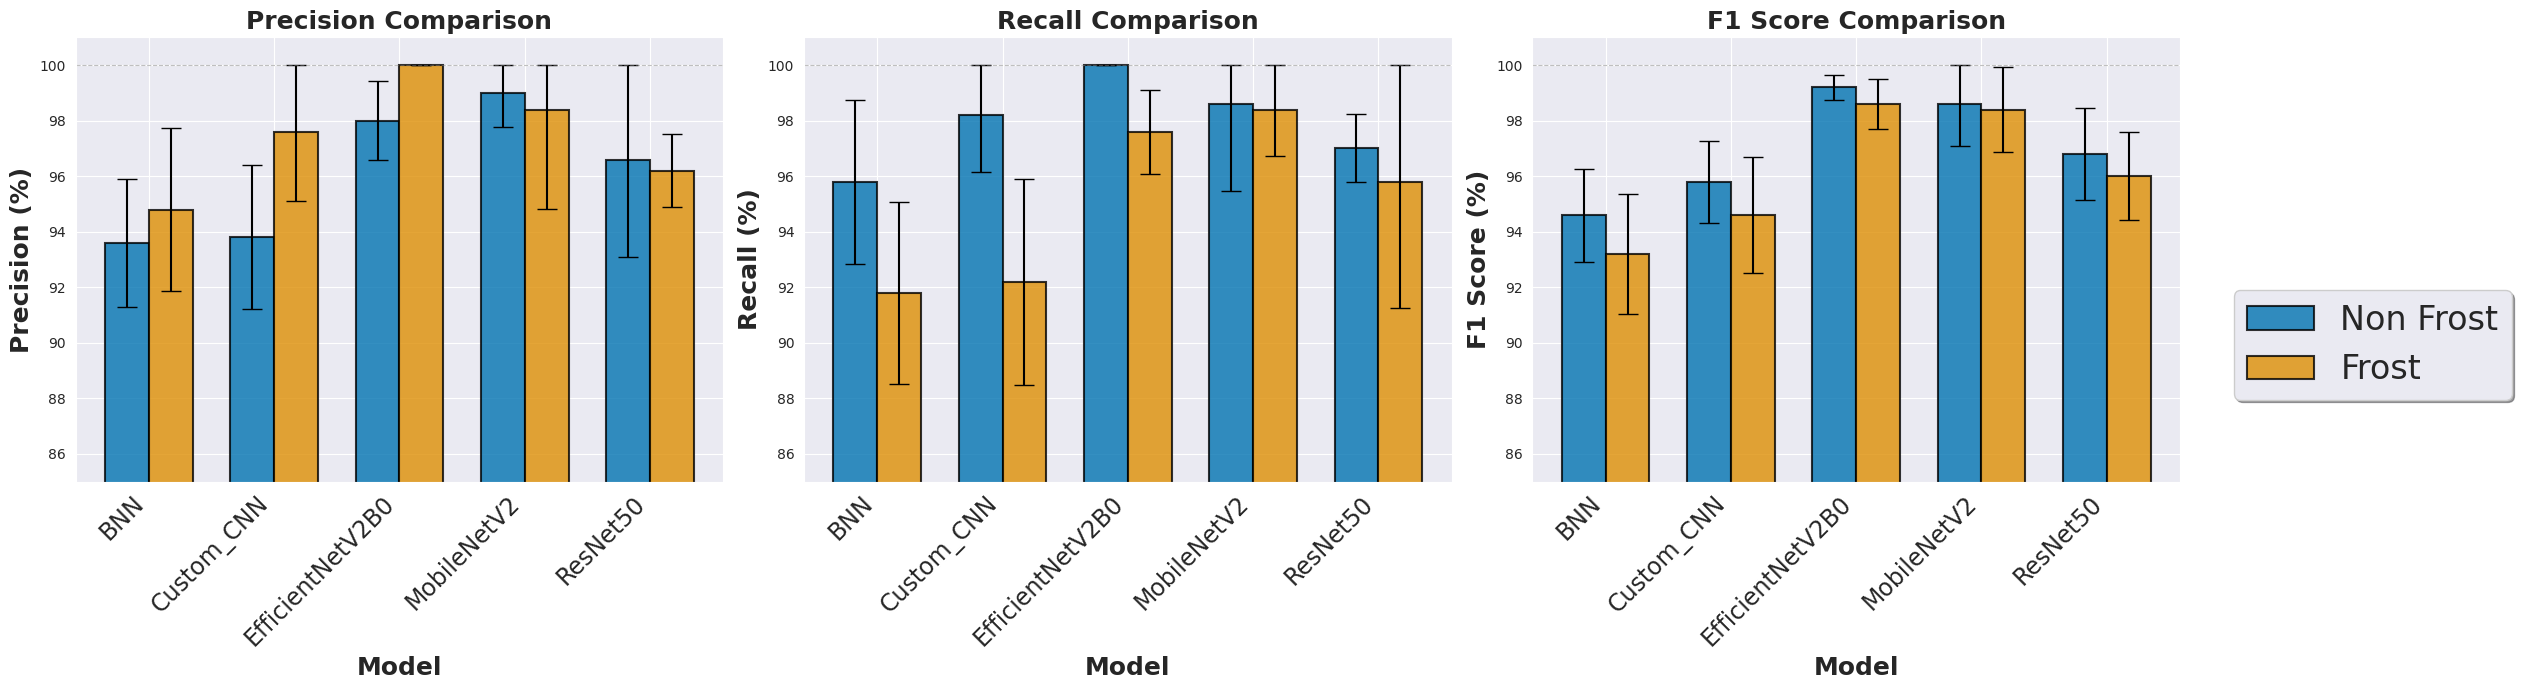


SUMMARY STATISTICS (Mean ± Std in %)

BNN:
  Precision: Non Frost = 93.6% ± 2.3%, Frost = 94.8% ± 2.9%
  Recall:    Non Frost = 95.8% ± 2.9%, Frost = 91.8% ± 3.3%
  F1 Score:  Non Frost = 94.6% ± 1.7%, Frost = 93.2% ± 2.2%

Custom_CNN:
  Precision: Non Frost = 93.8% ± 2.6%, Frost = 97.6% ± 2.5%
  Recall:    Non Frost = 98.2% ± 2.0%, Frost = 92.2% ± 3.7%
  F1 Score:  Non Frost = 95.8% ± 1.5%, Frost = 94.6% ± 2.1%

EfficientNetV2B0:
  Precision: Non Frost = 98.0% ± 1.4%, Frost = 100.0% ± 0.0%
  Recall:    Non Frost = 100.0% ± 0.0%, Frost = 97.6% ± 1.5%
  F1 Score:  Non Frost = 99.2% ± 0.4%, Frost = 98.6% ± 0.9%

MobileNetV2:
  Precision: Non Frost = 99.0% ± 1.2%, Frost = 98.4% ± 3.6%
  Recall:    Non Frost = 98.6% ± 3.1%, Frost = 98.4% ± 1.7%
  F1 Score:  Non Frost = 98.6% ± 1.5%, Frost = 98.4% ± 1.5%

ResNet50:
  Precision: Non Frost = 96.6% ± 3.5%, Frost = 96.2% ± 1.3%
  Recall:    Non Frost = 97.0% ± 1.2%, Frost = 95.8% ± 4.5%
  F1 Score:  Non Frost = 96.8% ± 1.6%, Frost = 96.0% ± 1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# Read the data
df = pd.read_excel(file_path, sheet_name='ml_results_binary')

# Extract base model name (without fold number)
df['Base_Model'] = df['Model'].str.replace(r'_(f\d|test)$', '', regex=True)

# Filter only the cross-validation folds (exclude test set for now)
df_cv = df[df['Model'].str.contains('_f\d', regex=True)].copy()

# Calculate statistics per model
stats = df_cv.groupby('Base_Model').agg({
    'Precision Non Frost': ['mean', 'std'],
    'Recall Non Frost': ['mean', 'std'],
    'F1 Score Non frost': ['mean', 'std'],
    'Precision Frost': ['mean', 'std'],
    'Recall Frost': ['mean', 'std'],
    'F1 Score Frost': ['mean', 'std']
})

# Create combined plots with grouped bars
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
#fig.suptitle('Binary Classification Performance: Non Frost vs Frost (Mean ± Std over 5 CV Folds)',
#             fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('Precision', 'Precision Non Frost', 'Precision Frost'),
    ('Recall', 'Recall Non Frost', 'Recall Frost'),
    ('F1 Score', 'F1 Score Non frost', 'F1 Score Frost')
]

x = np.arange(len(stats.index))
width = 0.35  # Width of bars

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette('colorblind')
colors = [colorblind_palette[0], colorblind_palette[1]]  # Blue and Orange

for idx, (metric_name, non_frost_col, frost_col) in enumerate(metrics):
    ax = axes[idx]

    # Get means and stds and convert to percentages
    means_non_frost = stats[non_frost_col]['mean'] * 100
    stds_non_frost = stats[non_frost_col]['std'] * 100
    means_frost = stats[frost_col]['mean'] * 100
    stds_frost = stats[frost_col]['std'] * 100

    # Calculate error bars, but clip them so they don't exceed 100
    upper_err_non_frost = np.minimum(stds_non_frost, 100 - means_non_frost)
    upper_err_frost = np.minimum(stds_frost, 100 - means_frost)

    lower_err_non_frost = stds_non_frost
    lower_err_frost = stds_frost

    # Create asymmetric error bars
    errors_non_frost = [lower_err_non_frost, upper_err_non_frost]
    errors_frost = [lower_err_frost, upper_err_frost]

    # Create grouped bars
    bars1 = ax.bar(x - width/2, means_non_frost, width, yerr=errors_non_frost,
                   capsize=7, label='Non Frost', color=colors[0],
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2 = ax.bar(x + width/2, means_frost, width, yerr=errors_frost,
                   capsize=7, label='Frost', color=colors[1],
                   edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=18, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(85, 101)  # Set range from 85% to 102%
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)



# Create a single legend outside the plot area
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),
           fontsize=24, frameon=True, shadow=True, markerscale=1.5)

plt.tight_layout()

# Save the figure with 300 dpi
output_path = '/content/drive/My Drive/binary_classification_performance.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

# Print summary table
print("\n" + "="*100)
print("SUMMARY STATISTICS (Mean ± Std in %)")
print("="*100)
for model in stats.index:
    print(f"\n{model}:")
    print(f"  Precision: Non Frost = {stats.loc[model, ('Precision Non Frost', 'mean')]*100:.1f}% ± {stats.loc[model, ('Precision Non Frost', 'std')]*100:.1f}%, "
          f"Frost = {stats.loc[model, ('Precision Frost', 'mean')]*100:.1f}% ± {stats.loc[model, ('Precision Frost', 'std')]*100:.1f}%")
    print(f"  Recall:    Non Frost = {stats.loc[model, ('Recall Non Frost', 'mean')]*100:.1f}% ± {stats.loc[model, ('Recall Non Frost', 'std')]*100:.1f}%, "
          f"Frost = {stats.loc[model, ('Recall Frost', 'mean')]*100:.1f}% ± {stats.loc[model, ('Recall Frost', 'std')]*100:.1f}%")
    print(f"  F1 Score:  Non Frost = {stats.loc[model, ('F1 Score Non frost', 'mean')]*100:.1f}% ± {stats.loc[model, ('F1 Score Non frost', 'std')]*100:.1f}%, "
          f"Frost = {stats.loc[model, ('F1 Score Frost', 'mean')]*100:.1f}% ± {stats.loc[model, ('F1 Score Frost', 'std')]*100:.1f}%")

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-270599927.py:16: SyntaxWarning: invalid escape sequence '\d'
  df_cv = df[df['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/binary_misclassifications_stacked.tif


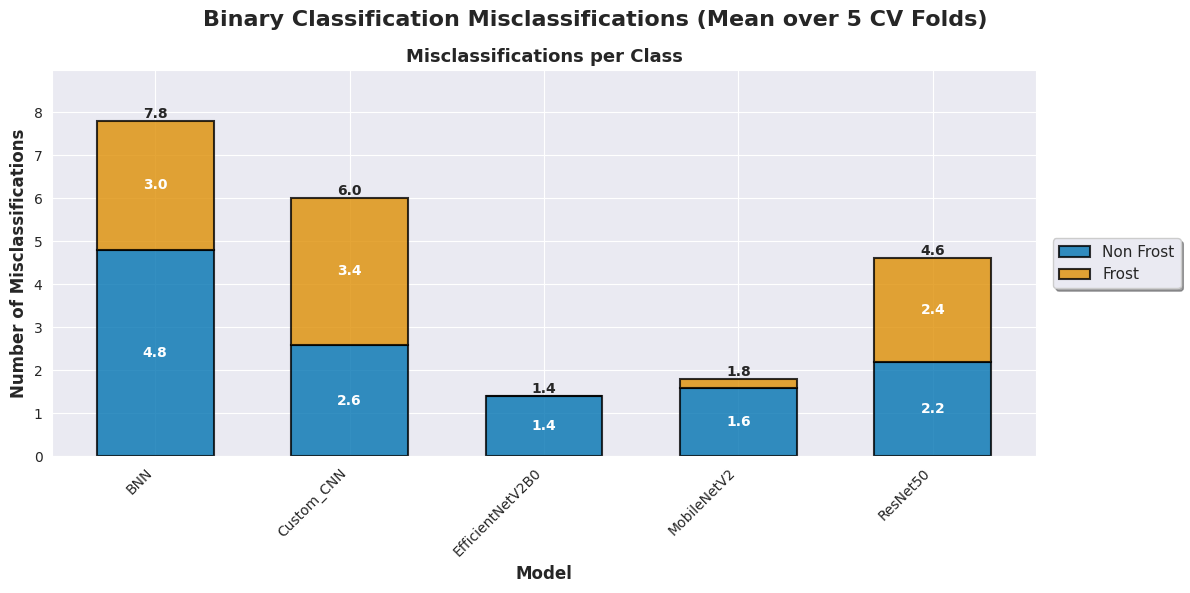


MISCLASSIFICATION STATISTICS (Mean ± Std)

BNN:
  Total: 7.80
  Non Frost: 4.80 ± 1.79
  Frost: 3.00 ± 1.87

Custom_CNN:
  Total: 6.00
  Non Frost: 2.60 ± 2.30
  Frost: 3.40 ± 2.70

EfficientNetV2B0:
  Total: 1.40
  Non Frost: 1.40 ± 0.89
  Frost: 0.00 ± 0.00

MobileNetV2:
  Total: 1.80
  Non Frost: 1.60 ± 2.07
  Frost: 0.20 ± 0.45

ResNet50:
  Total: 4.60
  Non Frost: 2.20 ± 0.84
  Frost: 2.40 ± 2.51


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# Read the binary data
df = pd.read_excel(file_path, sheet_name='ml_results_binary')

# Extract base model name (without fold number)
df['Base_Model'] = df['Model'].str.replace(r'_(f\d|test)$', '', regex=True)

# Filter only the cross-validation folds
df_cv = df[df['Model'].str.contains('_f\d', regex=True)].copy()

# Calculate statistics per model
stats_misclass = df_cv.groupby('Base_Model').agg({
    'Misclassification Non Frost': ['mean', 'std'],
    'Misclassifications Frost': ['mean', 'std']
})

# Create stacked bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle('Binary Classification Misclassifications (Mean over 5 CV Folds)',
             fontsize=16, fontweight='bold', y=0.98)

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette('colorblind')
colors = [colorblind_palette[0], colorblind_palette[1]]  # Blue, Orange

x = np.arange(len(stats_misclass.index))

means_non_frost = stats_misclass['Misclassification Non Frost']['mean']
means_frost = stats_misclass['Misclassifications Frost']['mean']

# Create stacked bars
bars1 = ax.bar(x, means_non_frost, width=0.6, label='Non Frost',
               color=colors[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x, means_frost, width=0.6, bottom=means_non_frost, label='Frost',
               color=colors[1], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=12, fontweight='bold')
ax.set_title('Misclassifications per Class', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stats_misclass.index, rotation=45, ha='right')
ax.set_ylim(0, max(means_non_frost + means_frost) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x)):
    total = means_non_frost.iloc[i] + means_frost.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Create legend outside plot
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=11, frameon=True, shadow=True)

plt.tight_layout()

# Save the figure
output_path = '/content/drive/My Drive/binary_misclassifications_stacked.tif'
plt.savefig(output_path, dpi=400, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

# Print summary
print("\n" + "="*80)
print("MISCLASSIFICATION STATISTICS (Mean ± Std)")
print("="*80)
for model in stats_misclass.index:
    total_mean = stats_misclass.loc[model, ('Misclassification Non Frost', 'mean')] + stats_misclass.loc[model, ('Misclassifications Frost', 'mean')]
    print(f"\n{model}:")
    print(f"  Total: {total_mean:.2f}")
    print(f"  Non Frost: {stats_misclass.loc[model, ('Misclassification Non Frost', 'mean')]:.2f} ± {stats_misclass.loc[model, ('Misclassification Non Frost', 'std')]:.2f}")
    print(f"  Frost: {stats_misclass.loc[model, ('Misclassifications Frost', 'mean')]:.2f} ± {stats_misclass.loc[model, ('Misclassifications Frost', 'std')]:.2f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the training dynamics data
df_dynamics = pd.read_excel(file_path, sheet_name='training_dynamics_binary')

# Check the structure
print("Column names:")
print(df_dynamics.columns.tolist())
print("\nFirst column values (these become our index):")
print(df_dynamics.iloc[:, 0].tolist())
print("\nFirst few rows:")
print(df_dynamics.head(15))

Column names:
['Learning Dynamics', 'Custom_CNN_f1', 'Custom_CNN_f2', 'Custom_CNN_f3', 'Custom_CNN_f4', 'Custom_CNN_f5', 'Custom_CNN_test', 'BNN_f1', 'BNN_f2', 'BNN_f3', 'BNN_f4', 'BNN_f5', 'BNN_test', 'MobileNetV2_f1', 'MobileNetV2_f2', 'MobileNetV2_f3', 'MobileNetV2_f4', 'MobileNetV2_f5', 'MobileNetV2_test', 'EfficientNetV2B0_f1', 'EfficientNetV2B0_f2', 'EfficientNetV2B0_f3', 'EfficientNetV2B0_f4', 'EfficientNetV2B0_f5', 'EfficientNetV2B0_test', 'ResNet50_f1', 'ResNet50_f2', 'ResNet50_f3', 'ResNet50_f4', 'ResNet50_f5', 'ResNet50_test']

First column values (these become our index):
['Training_intitial_accuracy', 'Training_25_accuracy', 'Training_middle_accuracy', 'Training_75_accuracy', 'Training_final_accuracy', 'Validation_initial_accuracy', 'Validation_25_accuracy', 'Validation_middle_accuracy', 'Validation_75_accuracy', 'Validation_final_accuracy', 'Training_intitial_loss', 'Training_25_loss', 'Training_middle_loss', 'Training_75_loss', 'Training_final_loss', 'Validation_initial_

In [ ]:
# Extract base model name (without fold number)
#df['Base_Model'] = df['Model'].str.replace(r'_(f\d|test)$', '', regex=True)

# Filter only the cross-validation folds (exclude test set for now)
#df_cv = df[df['Model'].str.contains('_f\d', regex=True)].copy()

# Multiclass


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path to your Excel file (complete the path with your folder structure)
file_path = '/content/drive/My Drive/SI_1_ML_Results_Binary_Multiclass.xlsx'

# Load the Excel file
xls = pd.ExcelFile(file_path)

# Print all sheet names to see what we have
print("Available sheets:")
print(xls.sheet_names)
print("\n" + "="*50 + "\n")

# Read a specific sheet by name
sheet_name = 'ml_results_multiclass'
df = pd.read_excel(file_path, sheet_name=sheet_name)

print(f"Sheet: {sheet_name}")
print("\nShape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nColumn names:")
print(df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Available sheets:
['ml_results_binary', 'training_dynamics_binary', 'stat_comparison_binary', 'ml_results_multiclass', 'training_dynamics_multiclass', 'stat_comparison_multiclass']


Sheet: ml_results_multiclass

Shape: (30, 23)

First few rows:
             Model  Accuracy  Loss  Total number of misclassifications  \
0    Custom_CNN_f1      0.95  0.14                                   3   
1    Custom_CNN_f2      0.90  0.36                                   6   
2    Custom_CNN_f3      0.86  0.39                                   8   
3    Custom_CNN_f4      0.94  0.18                                   3   
4    Custom_CNN_f5      0.96  0.22                                   2   
5  Custom_CNN_test      0.96  0.12                                   3   
6           BNN_f1      0.88  0.38                                   5   
7           BNN_f2      0.81  0.4

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3304017306.py:16: SyntaxWarning: invalid escape sequence '\d'
  df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/multiclass_classification_performance.tif


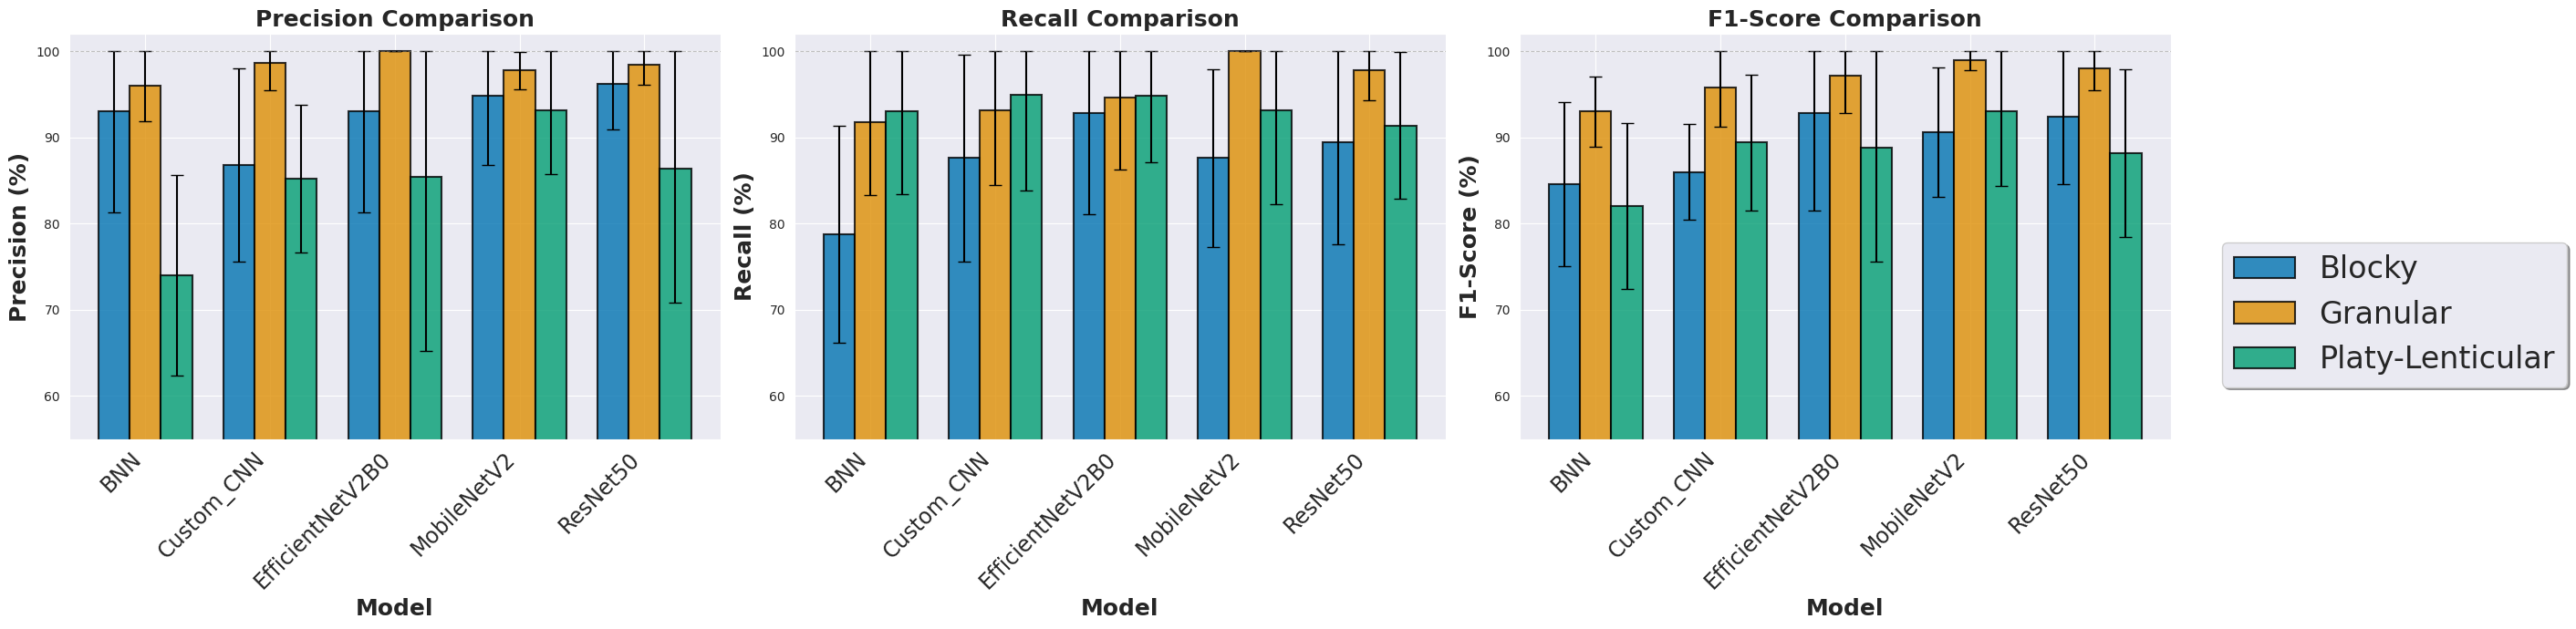


SUMMARY STATISTICS (Mean ± Std in %)

BNN:
  Precision: Blocky = 93.0% ± 11.7%, Granular = 96.0% ± 4.1%, Platy-Lenticular = 74.0% ± 11.7%
  Recall:    Blocky = 78.8% ± 12.6%, Granular = 91.8% ± 8.4%, Platy-Lenticular = 93.0% ± 9.6%
  F1-Score:  Blocky = 84.6% ± 9.5%, Granular = 93.0% ± 4.1%, Platy-Lenticular = 82.0% ± 9.6%

Custom_CNN:
  Precision: Blocky = 86.8% ± 11.3%, Granular = 98.6% ± 3.1%, Platy-Lenticular = 85.2% ± 8.6%
  Recall:    Blocky = 87.6% ± 12.0%, Granular = 93.2% ± 8.8%, Platy-Lenticular = 95.0% ± 11.2%
  F1-Score:  Blocky = 86.0% ± 5.5%, Granular = 95.8% ± 4.5%, Platy-Lenticular = 89.4% ± 7.9%

EfficientNetV2B0:
  Precision: Blocky = 93.0% ± 11.7%, Granular = 100.0% ± 0.0%, Platy-Lenticular = 85.4% ± 20.1%
  Recall:    Blocky = 92.8% ± 11.7%, Granular = 94.6% ± 8.4%, Platy-Lenticular = 94.8% ± 7.7%
  F1-Score:  Blocky = 92.8% ± 11.3%, Granular = 97.2% ± 4.4%, Platy-Lenticular = 88.8% ± 13.2%

MobileNetV2:
  Precision: Blocky = 94.8% ± 7.9%, Granular = 97.8% ± 2.2%, 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# Read the multiclass data
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')

# Extract base model name (without fold number)
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)

# Filter only the cross-validation folds (exclude test set)
df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()

# Calculate statistics per model
stats_multi = df_multi_cv.groupby('Base_Model').agg({
    'Precision  Blocky': ['mean', 'std'],  # Note the extra space in column name
    'Recall Blocky': ['mean', 'std'],
    'F1-Score Blocky': ['mean', 'std'],
    'Precision Granular': ['mean', 'std'],
    'Recall Granular': ['mean', 'std'],
    'F1-Score Granular': ['mean', 'std'],
    'Precision Platy-Lenticular': ['mean', 'std'],
    'Recall Platy-Lenticular': ['mean', 'std'],
    'F1-Score Platy-Lenticular': ['mean', 'std']
})

# Create combined plots with grouped bars
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
#fig.suptitle('Multiclass Classification Performance: Blocky vs Granular vs Platy-Lenticular (Mean ± Std over 5 CV Folds)',
#             fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('Precision', 'Precision  Blocky', 'Precision Granular', 'Precision Platy-Lenticular'),
    ('Recall', 'Recall Blocky', 'Recall Granular', 'Recall Platy-Lenticular'),
    ('F1-Score', 'F1-Score Blocky', 'F1-Score Granular', 'F1-Score Platy-Lenticular')
]

x = np.arange(len(stats_multi.index))
width = 0.25  # Width of bars (narrower for 3 classes)

# Use colorblind-friendly palette with 3 distinct colors
colorblind_palette = sns.color_palette('colorblind')
colors = [colorblind_palette[0], colorblind_palette[1], colorblind_palette[2]]  # Blue, Orange, Green

class_names = ['Blocky', 'Granular', 'Platy-Lenticular']

for idx, (metric_name, blocky_col, granular_col, platy_col) in enumerate(metrics):
    ax = axes[idx]

    columns = [blocky_col, granular_col, platy_col]

    for class_idx, (col, class_name, color) in enumerate(zip(columns, class_names, colors)):
        # Get means and stds and convert to percentages
        means = stats_multi[col]['mean'] * 100
        stds = stats_multi[col]['std'] * 100

        # Calculate error bars, but clip them so they don't exceed 100
        upper_err = np.minimum(stds, 100 - means)
        lower_err = stds

        # Create asymmetric error bars
        errors = [lower_err, upper_err]

        # Position bars: shift by width * (class_idx - 1)
        position = x + width * (class_idx - 1)

        # Create grouped bars
        bars = ax.bar(position, means, width, yerr=errors,
                     capsize=5, label=class_name, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)



    ax.set_xlabel('Model', fontsize=18, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(55, 102)  # Adjusted range for multiclass
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Create a single legend outside the plot area
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),
           fontsize=24, frameon=True, shadow=True , markerscale=1.5)

plt.tight_layout()

# Save the figure with 300 dpi
output_path = '/content/drive/My Drive/multiclass_classification_performance.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

# Print summary table
print("\n" + "="*120)
print("SUMMARY STATISTICS (Mean ± Std in %)")
print("="*120)
for model in stats_multi.index:
    print(f"\n{model}:")
    print(f"  Precision: Blocky = {stats_multi.loc[model, ('Precision  Blocky', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('Precision  Blocky', 'std')]*100:.1f}%, "
          f"Granular = {stats_multi.loc[model, ('Precision Granular', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('Precision Granular', 'std')]*100:.1f}%, "
          f"Platy-Lenticular = {stats_multi.loc[model, ('Precision Platy-Lenticular', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('Precision Platy-Lenticular', 'std')]*100:.1f}%")
    print(f"  Recall:    Blocky = {stats_multi.loc[model, ('Recall Blocky', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('Recall Blocky', 'std')]*100:.1f}%, "
          f"Granular = {stats_multi.loc[model, ('Recall Granular', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('Recall Granular', 'std')]*100:.1f}%, "
          f"Platy-Lenticular = {stats_multi.loc[model, ('Recall Platy-Lenticular', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('Recall Platy-Lenticular', 'std')]*100:.1f}%")
    print(f"  F1-Score:  Blocky = {stats_multi.loc[model, ('F1-Score Blocky', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('F1-Score Blocky', 'std')]*100:.1f}%, "
          f"Granular = {stats_multi.loc[model, ('F1-Score Granular', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('F1-Score Granular', 'std')]*100:.1f}%, "
          f"Platy-Lenticular = {stats_multi.loc[model, ('F1-Score Platy-Lenticular', 'mean')]*100:.1f}% ± {stats_multi.loc[model, ('F1-Score Platy-Lenticular', 'std')]*100:.1f}%")

<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3475052363.py:16: SyntaxWarning: invalid escape sequence '\d'
  df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/multiclass_misclassifications_stacked.tif


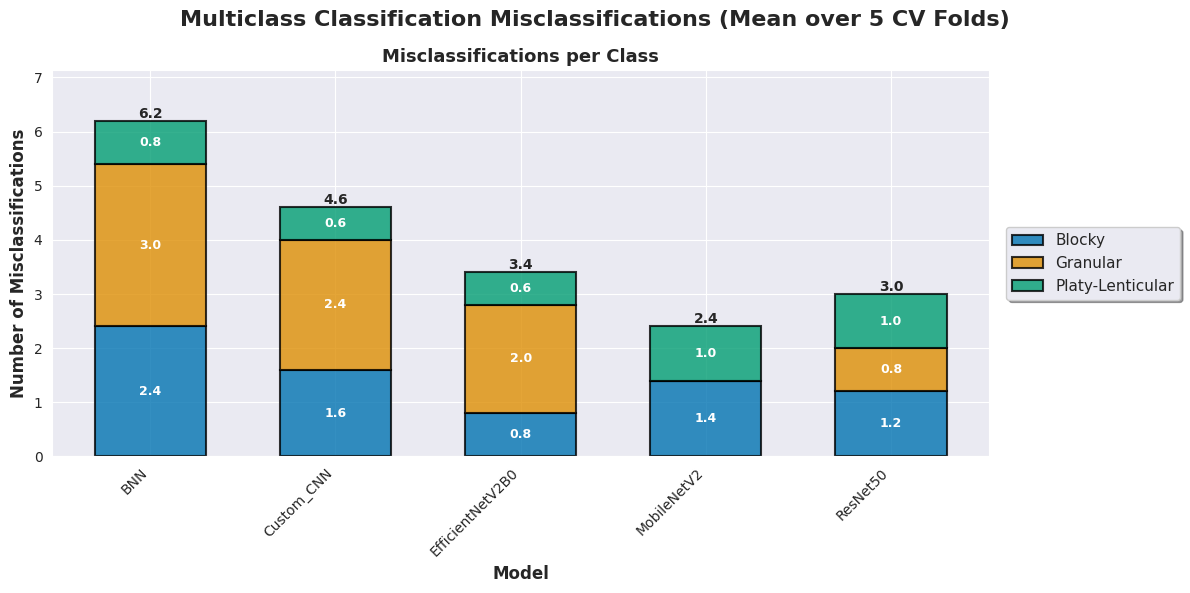


MISCLASSIFICATION STATISTICS (Mean ± Std)

BNN:
  Total: 6.20
  Blocky: 2.40 ± 1.34
  Granular: 3.00 ± 3.08
  Platy-Lenticular: 0.80 ± 1.10

Custom_CNN:
  Total: 4.60
  Blocky: 1.60 ± 1.52
  Granular: 2.40 ± 3.21
  Platy-Lenticular: 0.60 ± 1.34

EfficientNetV2B0:
  Total: 3.40
  Blocky: 0.80 ± 1.30
  Granular: 2.00 ± 3.08
  Platy-Lenticular: 0.60 ± 0.89

MobileNetV2:
  Total: 2.40
  Blocky: 1.40 ± 1.14
  Granular: 0.00 ± 0.00
  Platy-Lenticular: 1.00 ± 1.22

ResNet50:
  Total: 3.00
  Blocky: 1.20 ± 1.30
  Granular: 0.80 ± 1.30
  Platy-Lenticular: 1.00 ± 1.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# Read the multiclass data
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')

# Extract base model name
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)

# Filter only CV folds
df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()

# Calculate statistics per model
stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
    'Misclassifications Blocky': ['mean', 'std'],
    'Misclassifications Granular': ['mean', 'std'],
    'Misclassifications Platy-Lenticular': ['mean', 'std']
})

# Create stacked bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle('Multiclass Classification Misclassifications (Mean over 5 CV Folds)',
             fontsize=16, fontweight='bold', y=0.98)

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette('colorblind')
colors = [colorblind_palette[0], colorblind_palette[1], colorblind_palette[2]]  # Blue, Orange, Green

x = np.arange(len(stats_misclass_multi.index))

means_blocky = stats_misclass_multi['Misclassifications Blocky']['mean']
means_granular = stats_misclass_multi['Misclassifications Granular']['mean']
means_platy = stats_misclass_multi['Misclassifications Platy-Lenticular']['mean']

# Create stacked bars
bars1 = ax.bar(x, means_blocky, width=0.6, label='Blocky',
               color=colors[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x, means_granular, width=0.6, bottom=means_blocky, label='Granular',
               color=colors[1], edgecolor='black', linewidth=1.5, alpha=0.8)
bars3 = ax.bar(x, means_platy, width=0.6, bottom=means_blocky + means_granular,
               label='Platy-Lenticular', color=colors[2], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=12, fontweight='bold')
ax.set_title('Misclassifications per Class', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stats_misclass_multi.index, rotation=45, ha='right')
ax.set_ylim(0, max(means_blocky + means_granular + means_platy) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.25:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x)):
    total = means_blocky.iloc[i] + means_granular.iloc[i] + means_platy.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Create legend outside plot
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=11, frameon=True, shadow=True)

plt.tight_layout()

# Save the figure
output_path = '/content/drive/My Drive/multiclass_misclassifications_stacked.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

# Print summary
print("\n" + "="*100)
print("MISCLASSIFICATION STATISTICS (Mean ± Std)")
print("="*100)
for model in stats_misclass_multi.index:
    total_mean = (stats_misclass_multi.loc[model, ('Misclassifications Blocky', 'mean')] +
                  stats_misclass_multi.loc[model, ('Misclassifications Granular', 'mean')] +
                  stats_misclass_multi.loc[model, ('Misclassifications Platy-Lenticular', 'mean')])
    print(f"\n{model}:")
    print(f"  Total: {total_mean:.2f}")
    print(f"  Blocky: {stats_misclass_multi.loc[model, ('Misclassifications Blocky', 'mean')]:.2f} ± {stats_misclass_multi.loc[model, ('Misclassifications Blocky', 'std')]:.2f}")
    print(f"  Granular: {stats_misclass_multi.loc[model, ('Misclassifications Granular', 'mean')]:.2f} ± {stats_misclass_multi.loc[model, ('Misclassifications Granular', 'std')]:.2f}")
    print(f"  Platy-Lenticular: {stats_misclass_multi.loc[model, ('Misclassifications Platy-Lenticular', 'mean')]:.2f} ± {stats_misclass_multi.loc[model, ('Misclassifications Platy-Lenticular', 'std')]:.2f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the training dynamics data
df_dynamics = pd.read_excel(file_path, sheet_name='training_dynamics_multiclass')

# Check the structure
print("Column names:")
print(df_dynamics.columns.tolist())
print("\nFirst column values (these become our index):")
print(df_dynamics.iloc[:, 0].tolist())
print("\nFirst few rows:")
print(df_dynamics.head(15))

Column names:
['Learning Dynamics', 'Custom_CNN_f1', 'Custom_CNN_f2', 'Custom_CNN_f3', 'Custom_CNN_f4', 'Custom_CNN_f5', 'Custom_CNN_test', 'BNN_f1', 'BNN_f2', 'BNN_f3', 'BNN_f4', 'BNN_f5', 'BNN_test', 'MobileNetV2_f1', 'MobileNetV2_f2', 'MobileNetV2_f3', 'MobileNetV2_f4', 'MobileNetV2_f5', 'MobileNetV2_test', 'EfficientNetV2B0_f1', 'EfficientNetV2B0_f2', 'EfficientNetV2B0_f3', 'EfficientNetV2B0_f4', 'EfficientNetV2B0_f5', 'EfficientNetV2B0_test', 'ResNet50_f1', 'ResNet50_f2', 'ResNet50_f3', 'ResNet50_f4', 'ResNet50_f5', 'ResNet50_test']

First column values (these become our index):
['Training_intitial_accuracy', 'Training_25_accuracy', 'Training_middle_accuracy', 'Training_75_accuracy', 'Training_final_accuracy', 'Validation_initial_accuracy', 'Validation_25_accuracy', 'Validation_middle_accuracy', 'Validation_75_accuracy', 'Validation_final_accuracy', 'Training_intitial_loss', 'Training_25_loss', 'Training_middle_loss', 'Training_75_loss', 'Training_final_loss', 'Validation_initial_

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-635430605.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()
/tmp/ipython-input-635430605.py:30: SyntaxWarning: invalid escape sequence '\d'
  df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/combined_classification_performance.tif


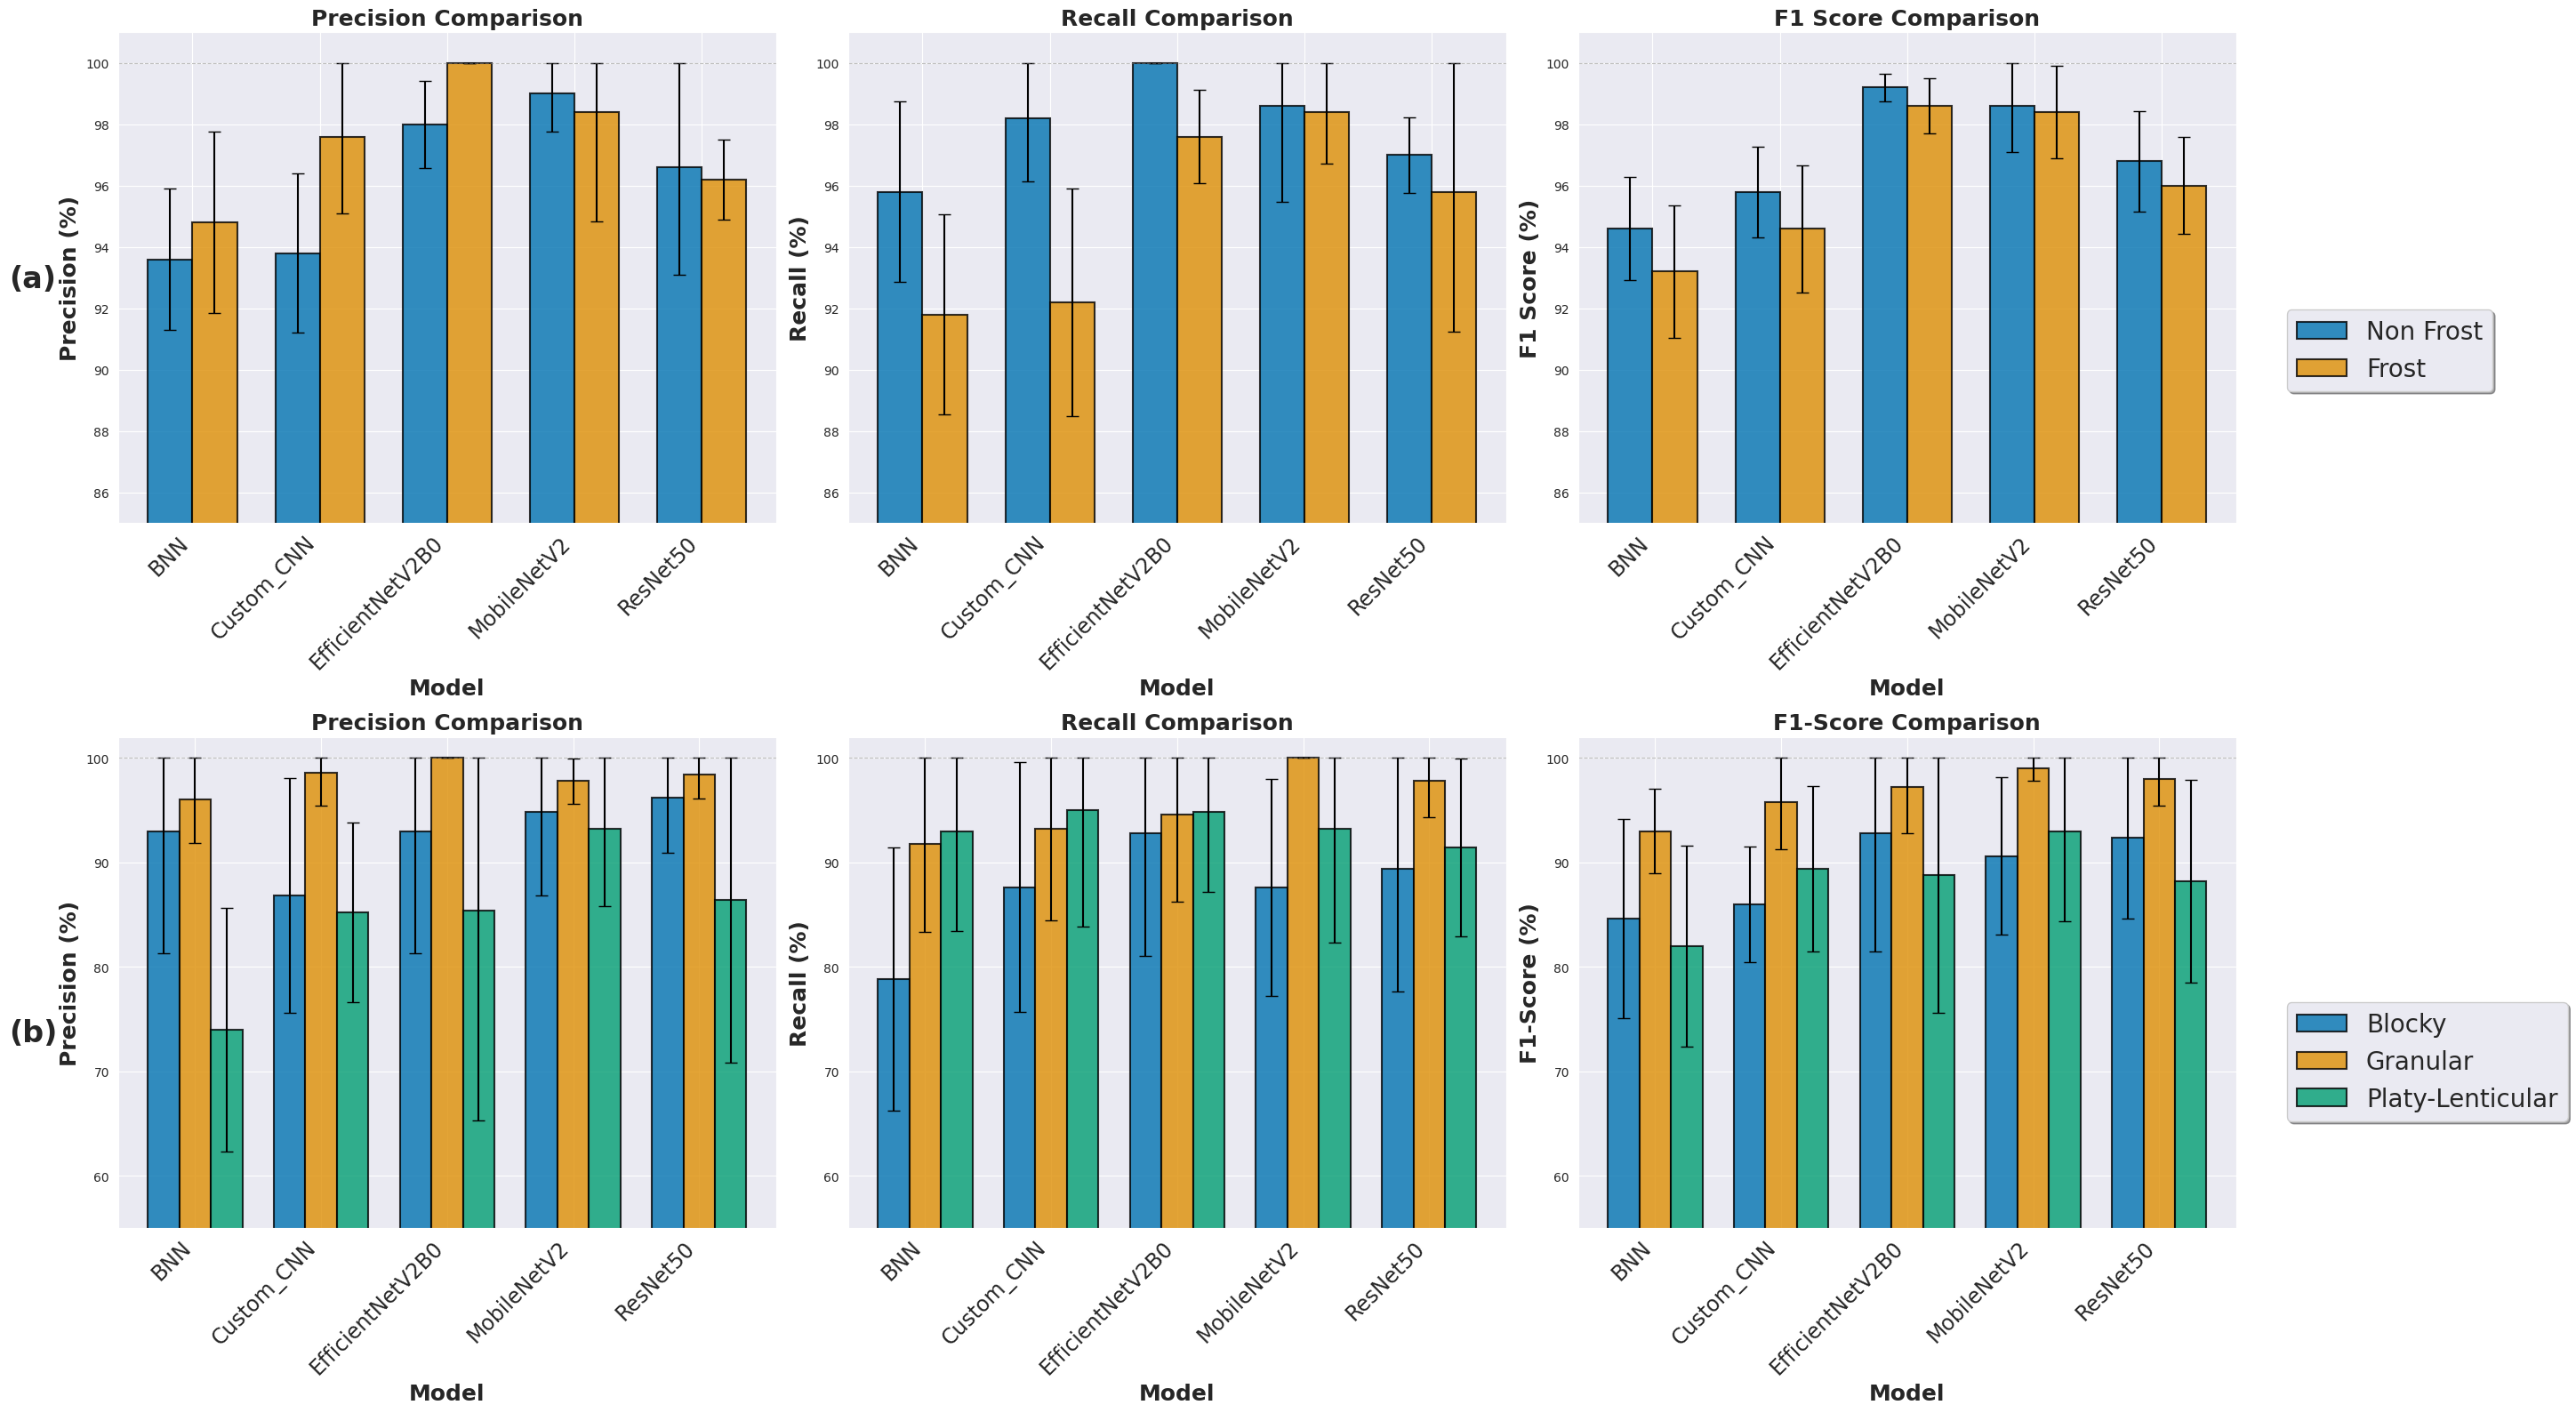

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()

stats_binary = df_binary_cv.groupby('Base_Model').agg({
    'Precision Non Frost': ['mean', 'std'],
    'Recall Non Frost': ['mean', 'std'],
    'F1 Score Non frost': ['mean', 'std'],
    'Precision Frost': ['mean', 'std'],
    'Recall Frost': ['mean', 'std'],
    'F1 Score Frost': ['mean', 'std']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()

stats_multi = df_multi_cv.groupby('Base_Model').agg({
    'Precision  Blocky': ['mean', 'std'],
    'Recall Blocky': ['mean', 'std'],
    'F1-Score Blocky': ['mean', 'std'],
    'Precision Granular': ['mean', 'std'],
    'Recall Granular': ['mean', 'std'],
    'F1-Score Granular': ['mean', 'std'],
    'Precision Platy-Lenticular': ['mean', 'std'],
    'Recall Platy-Lenticular': ['mean', 'std'],
    'F1-Score Platy-Lenticular': ['mean', 'std']
})

# ==========================================
# CREATE 2x3 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(28, 16))
plt.subplots_adjust(hspace=0.4)

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette('colorblind')

# ==========================================
# PLOT BINARY CLASSIFICATION (TOP ROW)
# ==========================================
metrics_binary = [
    ('Precision', 'Precision Non Frost', 'Precision Frost'),
    ('Recall', 'Recall Non Frost', 'Recall Frost'),
    ('F1 Score', 'F1 Score Non frost', 'F1 Score Frost')
]

x_binary = np.arange(len(stats_binary.index))
width_binary = 0.35
colors_binary = [colorblind_palette[0], colorblind_palette[1]]  # Blue and Orange

for idx, (metric_name, non_frost_col, frost_col) in enumerate(metrics_binary):
    ax = axes[0, idx]  # First row

    # Get means and stds and convert to percentages
    means_non_frost = stats_binary[non_frost_col]['mean'] * 100
    stds_non_frost = stats_binary[non_frost_col]['std'] * 100
    means_frost = stats_binary[frost_col]['mean'] * 100
    stds_frost = stats_binary[frost_col]['std'] * 100

    # Calculate error bars
    upper_err_non_frost = np.minimum(stds_non_frost, 100 - means_non_frost)
    upper_err_frost = np.minimum(stds_frost, 100 - means_frost)
    lower_err_non_frost = stds_non_frost
    lower_err_frost = stds_frost

    errors_non_frost = [lower_err_non_frost, upper_err_non_frost]
    errors_frost = [lower_err_frost, upper_err_frost]

    # Create grouped bars
    bars1 = ax.bar(x_binary - width_binary/2, means_non_frost, width_binary, yerr=errors_non_frost,
                   capsize=5, label='Non Frost', color=colors_binary[0],
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2 = ax.bar(x_binary + width_binary/2, means_frost, width_binary, yerr=errors_frost,
                   capsize=5, label='Frost', color=colors_binary[1],
                   edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=18, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=18, fontweight='bold')
    ax.set_xticks(x_binary)
    ax.set_xticklabels(stats_binary.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(85, 101)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Add (a) label for binary classification
fig.text(0.01, 0.80, '(a)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# PLOT MULTICLASS CLASSIFICATION (BOTTOM ROW)
# ==========================================
metrics_multi = [
    ('Precision', 'Precision  Blocky', 'Precision Granular', 'Precision Platy-Lenticular'),
    ('Recall', 'Recall Blocky', 'Recall Granular', 'Recall Platy-Lenticular'),
    ('F1-Score', 'F1-Score Blocky', 'F1-Score Granular', 'F1-Score Platy-Lenticular')
]

x_multi = np.arange(len(stats_multi.index))
width_multi = 0.25
colors_multi = [colorblind_palette[0], colorblind_palette[1], colorblind_palette[2]]  # Blue, Orange, Green
class_names = ['Blocky', 'Granular', 'Platy-Lenticular']

for idx, (metric_name, blocky_col, granular_col, platy_col) in enumerate(metrics_multi):
    ax = axes[1, idx]  # Second row

    columns = [blocky_col, granular_col, platy_col]

    for class_idx, (col, class_name, color) in enumerate(zip(columns, class_names, colors_multi)):
        # Get means and stds and convert to percentages
        means = stats_multi[col]['mean'] * 100
        stds = stats_multi[col]['std'] * 100

        # Calculate error bars
        upper_err = np.minimum(stds, 100 - means)
        lower_err = stds
        errors = [lower_err, upper_err]

        # Position bars
        position = x_multi + width_multi * (class_idx - 1)

        # Create grouped bars
        bars = ax.bar(position, means, width_multi, yerr=errors,
                     capsize=5, label=class_name, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=18, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=18, fontweight='bold')
    ax.set_xticks(x_multi)
    ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(55, 102)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Add (b) label for multiclass classification
fig.text(0.01, 0.27, '(b)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# ADD LEGENDS ON THE RIGHT SIDE OF EACH ROW
# ==========================================
# Legend for binary (right side of top row)
handles_binary, labels_binary = axes[0, 0].get_legend_handles_labels()
legend_binary = fig.legend(handles_binary, labels_binary,
                          loc='center left', bbox_to_anchor=(0.92, 0.75),
                          fontsize=20, frameon=True, shadow=True, markerscale=1.5)

# Legend for multiclass (right side of bottom row)
handles_multi, labels_multi = axes[1, 0].get_legend_handles_labels()
legend_multi = fig.legend(handles_multi, labels_multi,
                         loc='center left', bbox_to_anchor=(0.92, 0.25),
                         fontsize=20, frameon=True, shadow=True, markerscale=1.5)

plt.tight_layout(rect=[0.025, 0, 0.91, 1])  # Leave space on the right for legends

# Save the figure
output_path = '/content/drive/My Drive/combined_classification_performance.tif'
plt.savefig(output_path, dpi=400, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

Available columns in multiclass data:
['Total number of misclassifications', 'Misclassifications Blocky', 'Misclassifications Granular', 'Misclassifications Platy-Lenticular']
Figure saved to: /content/drive/My Drive/combined_misclassifications_stacked.tif


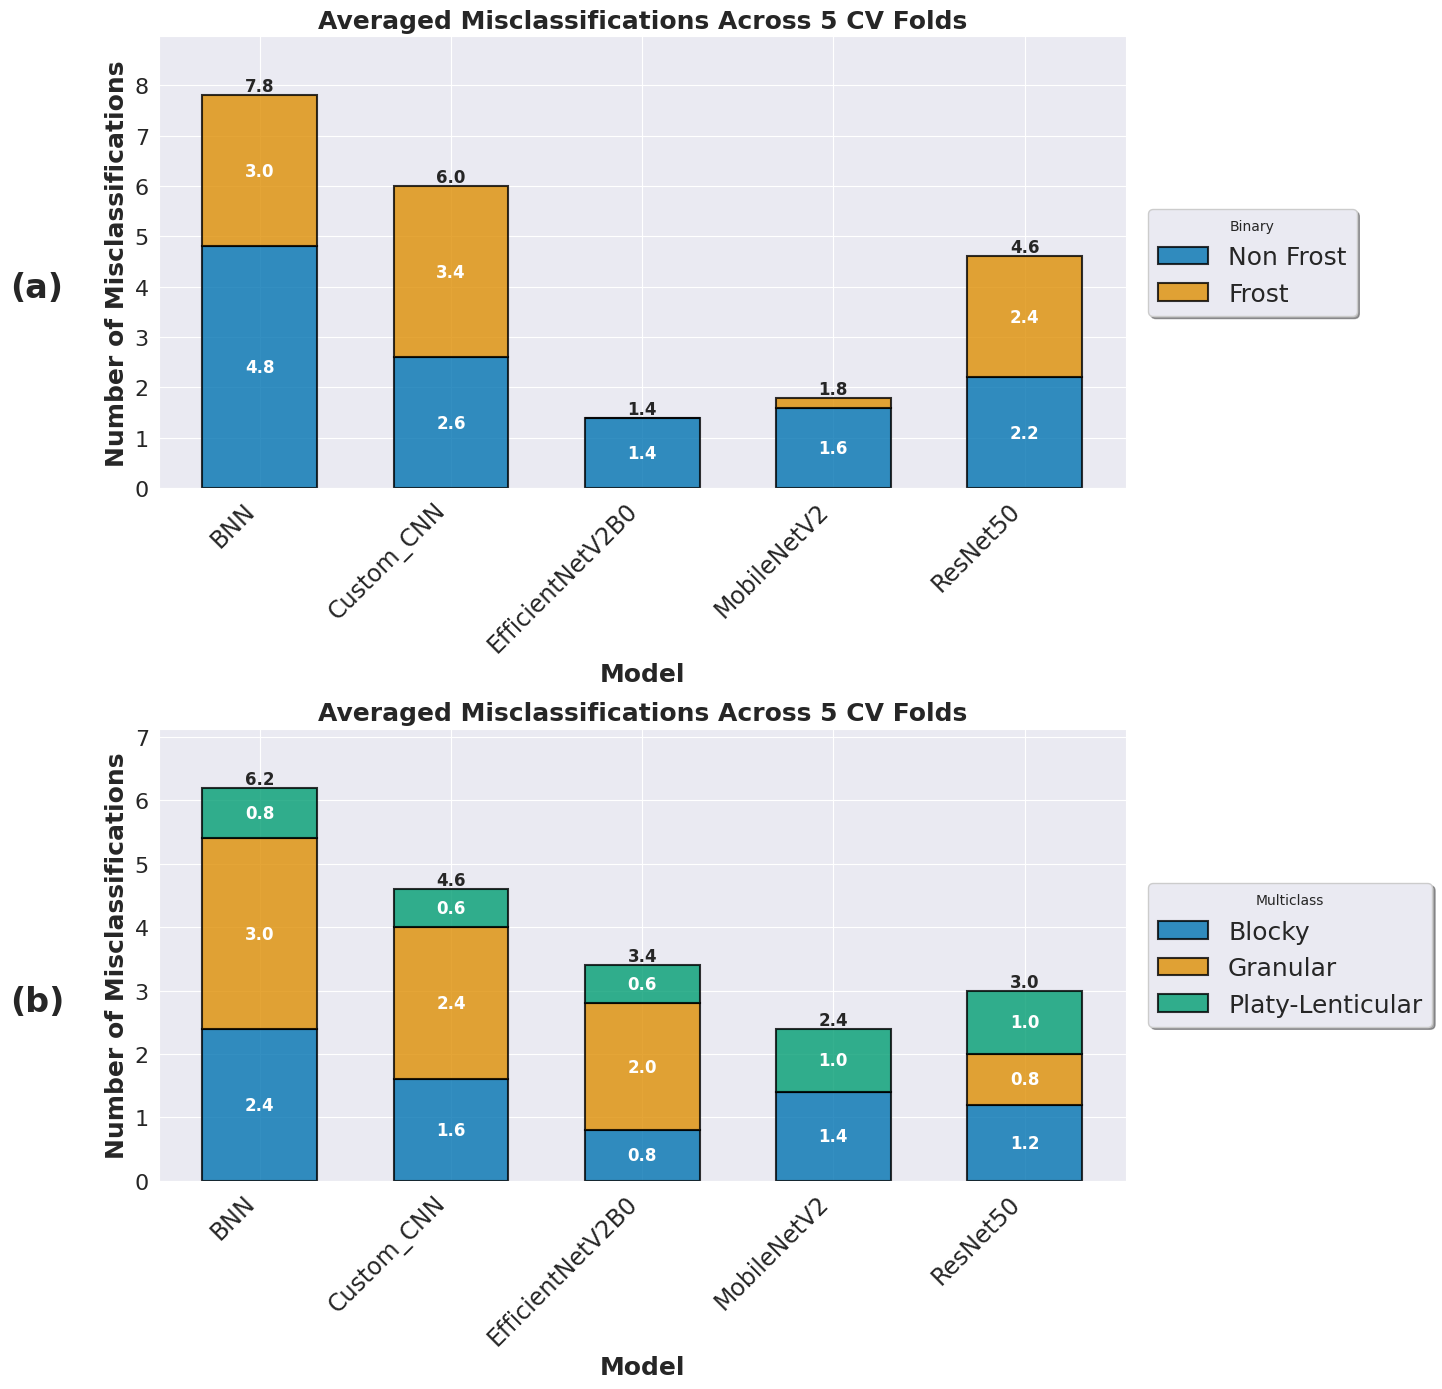

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains(r'_f\d', regex=True)].copy()

# Calculate misclassification statistics for binary
stats_misclass_binary = df_binary_cv.groupby('Base_Model').agg({
    'Misclassification Non Frost': ['mean', 'std'],
    'Misclassifications Frost': ['mean', 'std']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains(r'_f\d', regex=True)].copy()

# Check what misclassification columns exist in multiclass data
print("Available columns in multiclass data:")
print([col for col in df_multi_cv.columns if 'isclass' in col.lower()])

# Calculate misclassification statistics for multiclass
# Try with possible column name variations
try:
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassifications Blocky': ['mean', 'std'],
        'Misclassifications Granular': ['mean', 'std'],
        'Misclassifications Platy-Lenticular': ['mean', 'std']
    })
except KeyError:
    # If that doesn't work, try without 's'
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassification Blocky': ['mean', 'std'],
        'Misclassification Granular': ['mean', 'std'],
        'Misclassification Platy-Lenticular': ['mean', 'std']
    })

# ==========================================
# CREATE 2x1 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette('colorblind')

# ==========================================
# PLOT BINARY MISCLASSIFICATIONS (TOP)
# ==========================================
ax = axes[0]

colors_binary = [colorblind_palette[0], colorblind_palette[1]]  # Blue, Orange
x_binary = np.arange(len(stats_misclass_binary.index))

means_non_frost = stats_misclass_binary['Misclassification Non Frost']['mean']
means_frost = stats_misclass_binary['Misclassifications Frost']['mean']

# Create stacked bars
bars1 = ax.bar(x_binary, means_non_frost, width=0.6, label='Non Frost',
               color=colors_binary[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_binary, means_frost, width=0.6, bottom=means_non_frost, label='Frost',
               color=colors_binary[1], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
ax.set_title('Averaged Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_binary)
ax.set_xticklabels(stats_misclass_binary.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(means_non_frost + means_frost) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_binary)):
    total = means_non_frost.iloc[i] + means_frost.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add (a) label
fig.text(-0.02, 0.79, '(a)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# PLOT MULTICLASS MISCLASSIFICATIONS (BOTTOM)
# ==========================================
ax = axes[1]

colors_multi = [colorblind_palette[0], colorblind_palette[1], colorblind_palette[2]]  # Blue, Orange, Green
x_multi = np.arange(len(stats_misclass_multi.index))

# Get the first column name to determine if it's 'Misclassification' or 'Misclassifications'
first_col = list(stats_misclass_multi.columns.levels[0])[0]
col_prefix = 'Misclassifications' if first_col.startswith('Misclassifications') else 'Misclassification'

means_blocky = stats_misclass_multi[first_col]['mean']
means_granular = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[1]]['mean']
means_platy = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[2]]['mean']

# Create stacked bars
bars1 = ax.bar(x_multi, means_blocky, width=0.6, label='Blocky',
               color=colors_multi[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_multi, means_granular, width=0.6, bottom=means_blocky, label='Granular',
               color=colors_multi[1], edgecolor='black', linewidth=1.5, alpha=0.8)
bars3 = ax.bar(x_multi, means_platy, width=0.6, bottom=means_blocky + means_granular,
               label='Platy-Lenticular', color=colors_multi[2], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
ax.set_title('Averaged Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_multi)
ax.set_xticklabels(stats_misclass_multi.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(means_blocky + means_granular + means_platy) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_multi)):
    total = means_blocky.iloc[i] + means_granular.iloc[i] + means_platy.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add (b) label
fig.text(-0.02, 0.28, '(b)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# ADD LEGENDS ON THE RIGHT SIDE
# ==========================================
# Legend for binary (top)
handles_binary, labels_binary = axes[0].get_legend_handles_labels()
legend_binary = axes[0].legend(handles_binary, labels_binary,
                               loc='center left', bbox_to_anchor=(1.01, 0.5),
                               fontsize=18, frameon=True, shadow=True, markerscale=1.5,
                               title='Binary')

# Legend for multiclass (bottom)
handles_multi, labels_multi = axes[1].get_legend_handles_labels()
legend_multi = axes[1].legend(handles_multi, labels_multi,
                              loc='center left', bbox_to_anchor=(1.01, 0.5),
                              fontsize=18, frameon=True, shadow=True, markerscale=1.5,
                              title='Multiclass')

plt.tight_layout(rect=[0.03, 0, 0.88, 1])

# Save the figure
output_path = '/content/drive/My Drive/combined_misclassifications_stacked.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

In [ ]:
# Check the distribution of misclassifications across folds
for model in df_binary_cv['Base_Model'].unique():
    fold_data = df_binary_cv[df_binary_cv['Base_Model'] == model]
    print(f"\n{model}:")
    print(fold_data[['Misclassification Non Frost', 'Misclassifications Frost']].describe())


Custom_CNN:
       Misclassification Non Frost  Misclassifications Frost
count                     5.000000                  5.000000
mean                      2.600000                  3.400000
std                       2.302173                  2.701851
min                       0.000000                  0.000000
25%                       1.000000                  2.000000
50%                       3.000000                  3.000000
75%                       3.000000                  5.000000
max                       6.000000                  7.000000

BNN:
       Misclassification Non Frost  Misclassifications Frost
count                     5.000000                  5.000000
mean                      4.800000                  3.000000
std                       1.788854                  1.870829
min                       2.000000                  1.000000
25%                       4.000000                  1.000000
50%                       6.000000                  4.000000
75%  

Available columns in multiclass data:
['Total number of misclassifications', 'Misclassifications Blocky', 'Misclassifications Granular', 'Misclassifications Platy-Lenticular']
Figure saved to: /content/drive/My Drive/combined_misclassifications_stacked_median.tif


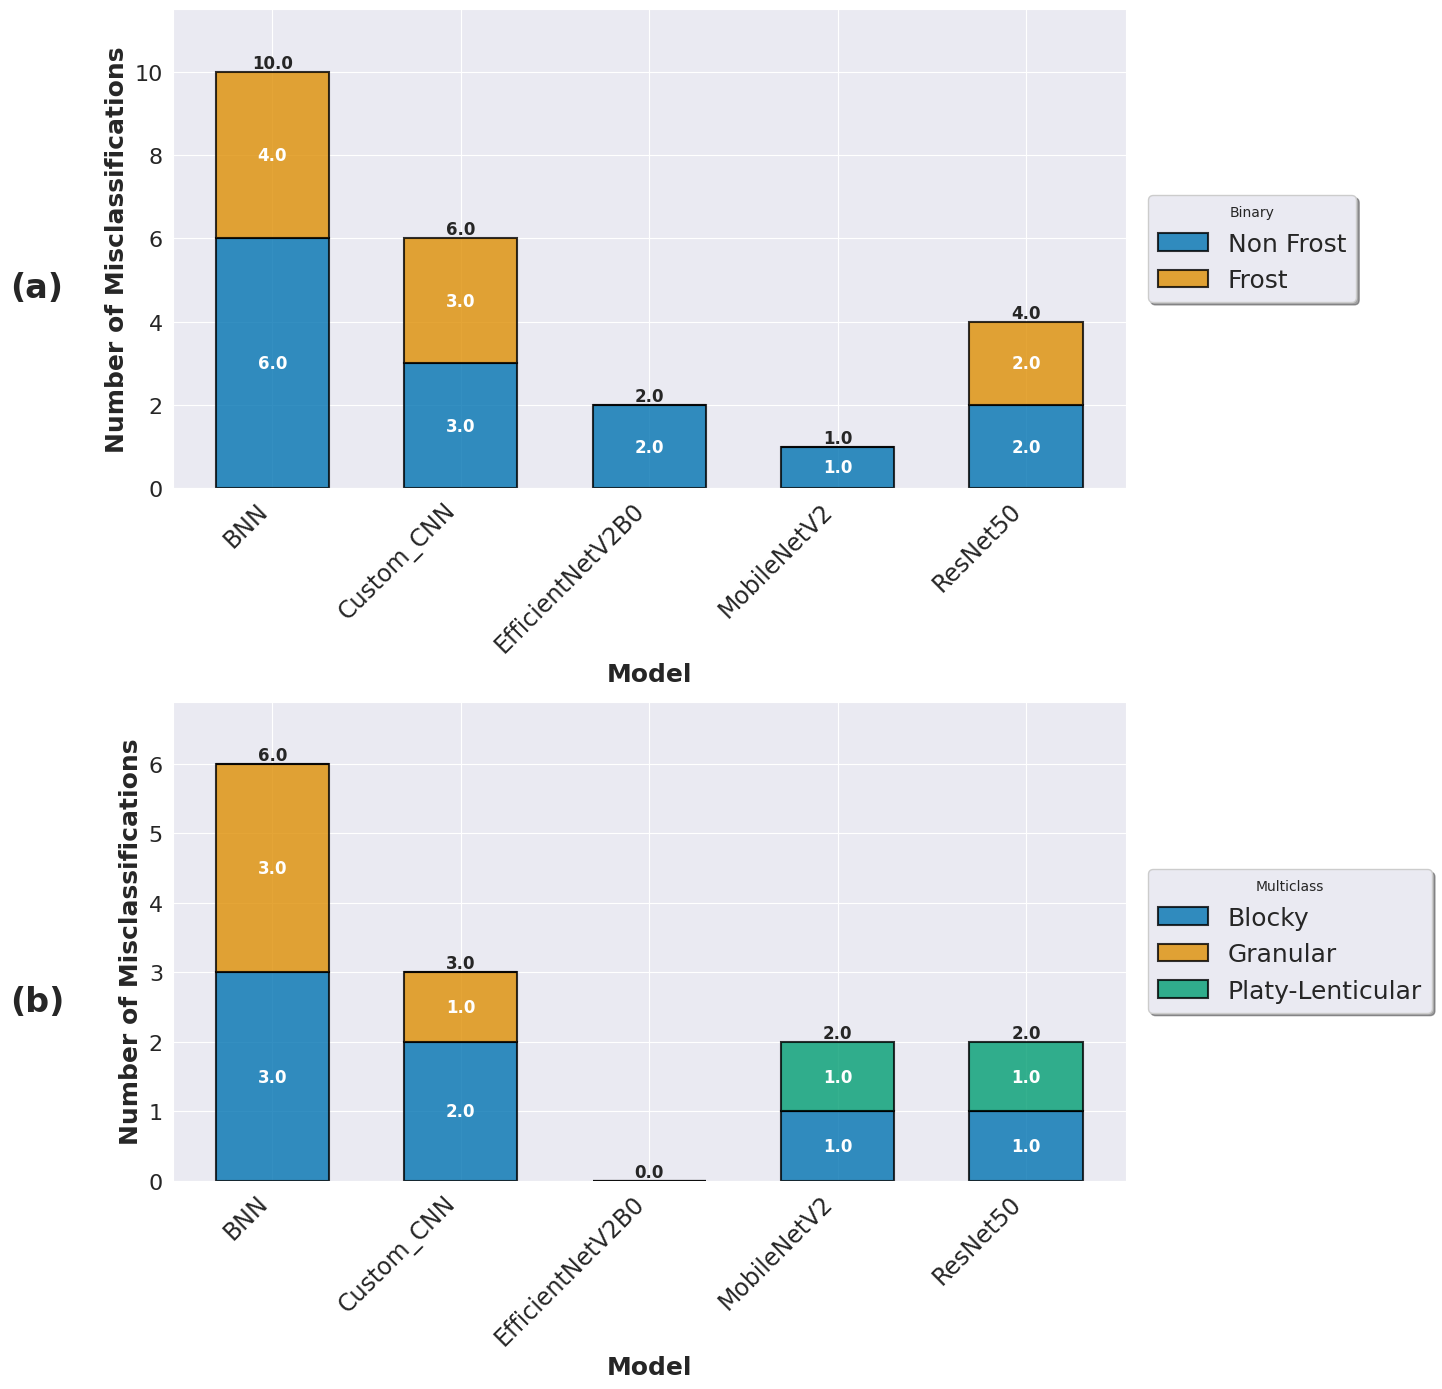

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains(r'_f\d', regex=True)].copy()

# Calculate misclassification statistics for binary - USING MEDIAN
stats_misclass_binary = df_binary_cv.groupby('Base_Model').agg({
    'Misclassification Non Frost': ['median'],
    'Misclassifications Frost': ['median']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains(r'_f\d', regex=True)].copy()

# Check what misclassification columns exist in multiclass data
print("Available columns in multiclass data:")
print([col for col in df_multi_cv.columns if 'isclass' in col.lower()])

# Calculate misclassification statistics for multiclass - USING MEDIAN
# Try with possible column name variations
try:
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassifications Blocky': ['median'],
        'Misclassifications Granular': ['median'],
        'Misclassifications Platy-Lenticular': ['median']
    })
except KeyError:
    # If that doesn't work, try without 's'
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassification Blocky': ['median'],
        'Misclassification Granular': ['median'],
        'Misclassification Platy-Lenticular': ['median']
    })

# ==========================================
# CREATE 2x1 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette('colorblind')

# ==========================================
# PLOT BINARY MISCLASSIFICATIONS (TOP)
# ==========================================
ax = axes[0]

colors_binary = [colorblind_palette[0], colorblind_palette[1]]  # Blue, Orange
x_binary = np.arange(len(stats_misclass_binary.index))

medians_non_frost = stats_misclass_binary['Misclassification Non Frost']['median']
medians_frost = stats_misclass_binary['Misclassifications Frost']['median']

# Create stacked bars
bars1 = ax.bar(x_binary, medians_non_frost, width=0.6, label='Non Frost',
               color=colors_binary[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_binary, medians_frost, width=0.6, bottom=medians_non_frost, label='Frost',
               color=colors_binary[1], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
#ax.set_title('Median Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_binary)
ax.set_xticklabels(stats_misclass_binary.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(medians_non_frost + medians_frost) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_binary)):
    total = medians_non_frost.iloc[i] + medians_frost.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add legend for binary
handles_binary, labels_binary = ax.get_legend_handles_labels()
ax.legend(handles_binary, labels_binary,
          loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=18, frameon=True, shadow=True, markerscale=1.5,
          title='Binary')

# Add (a) label
fig.text(-0.02, 0.79, '(a)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# PLOT MULTICLASS MISCLASSIFICATIONS (BOTTOM)
# ==========================================
ax = axes[1]

colors_multi = [colorblind_palette[0], colorblind_palette[1], colorblind_palette[2]]  # Blue, Orange, Green
x_multi = np.arange(len(stats_misclass_multi.index))

# Get the first column name to determine if it's 'Misclassification' or 'Misclassifications'
first_col = list(stats_misclass_multi.columns.levels[0])[0]
col_prefix = 'Misclassifications' if first_col.startswith('Misclassifications') else 'Misclassification'

medians_blocky = stats_misclass_multi[first_col]['median']
medians_granular = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[1]]['median']
medians_platy = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[2]]['median']

# Create stacked bars
bars1 = ax.bar(x_multi, medians_blocky, width=0.6, label='Blocky',
               color=colors_multi[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_multi, medians_granular, width=0.6, bottom=medians_blocky, label='Granular',
               color=colors_multi[1], edgecolor='black', linewidth=1.5, alpha=0.8)
bars3 = ax.bar(x_multi, medians_platy, width=0.6, bottom=medians_blocky + medians_granular,
               label='Platy-Lenticular', color=colors_multi[2], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
#ax.set_title('Median Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_multi)
ax.set_xticklabels(stats_misclass_multi.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(medians_blocky + medians_granular + medians_platy) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_multi)):
    total = medians_blocky.iloc[i] + medians_granular.iloc[i] + medians_platy.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add legend for multiclass
handles_multi, labels_multi = ax.get_legend_handles_labels()
ax.legend(handles_multi, labels_multi,
          loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=18, frameon=True, shadow=True, markerscale=1.5,
          title='Multiclass')

# Add (b) label
fig.text(-0.02, 0.28, '(b)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# ADJUST LAYOUT AND SAVE
# ==========================================
plt.tight_layout(rect=[0.03, 0, 0.88, 1])

# Save the figure
output_path = '/content/drive/My Drive/combined_misclassifications_stacked_median.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

Available columns in multiclass data:
['Total number of misclassifications', 'Misclassifications Blocky', 'Misclassifications Granular', 'Misclassifications Platy-Lenticular']
Figure saved to: /content/drive/My Drive/combined_misclassifications_stacked_median.tif


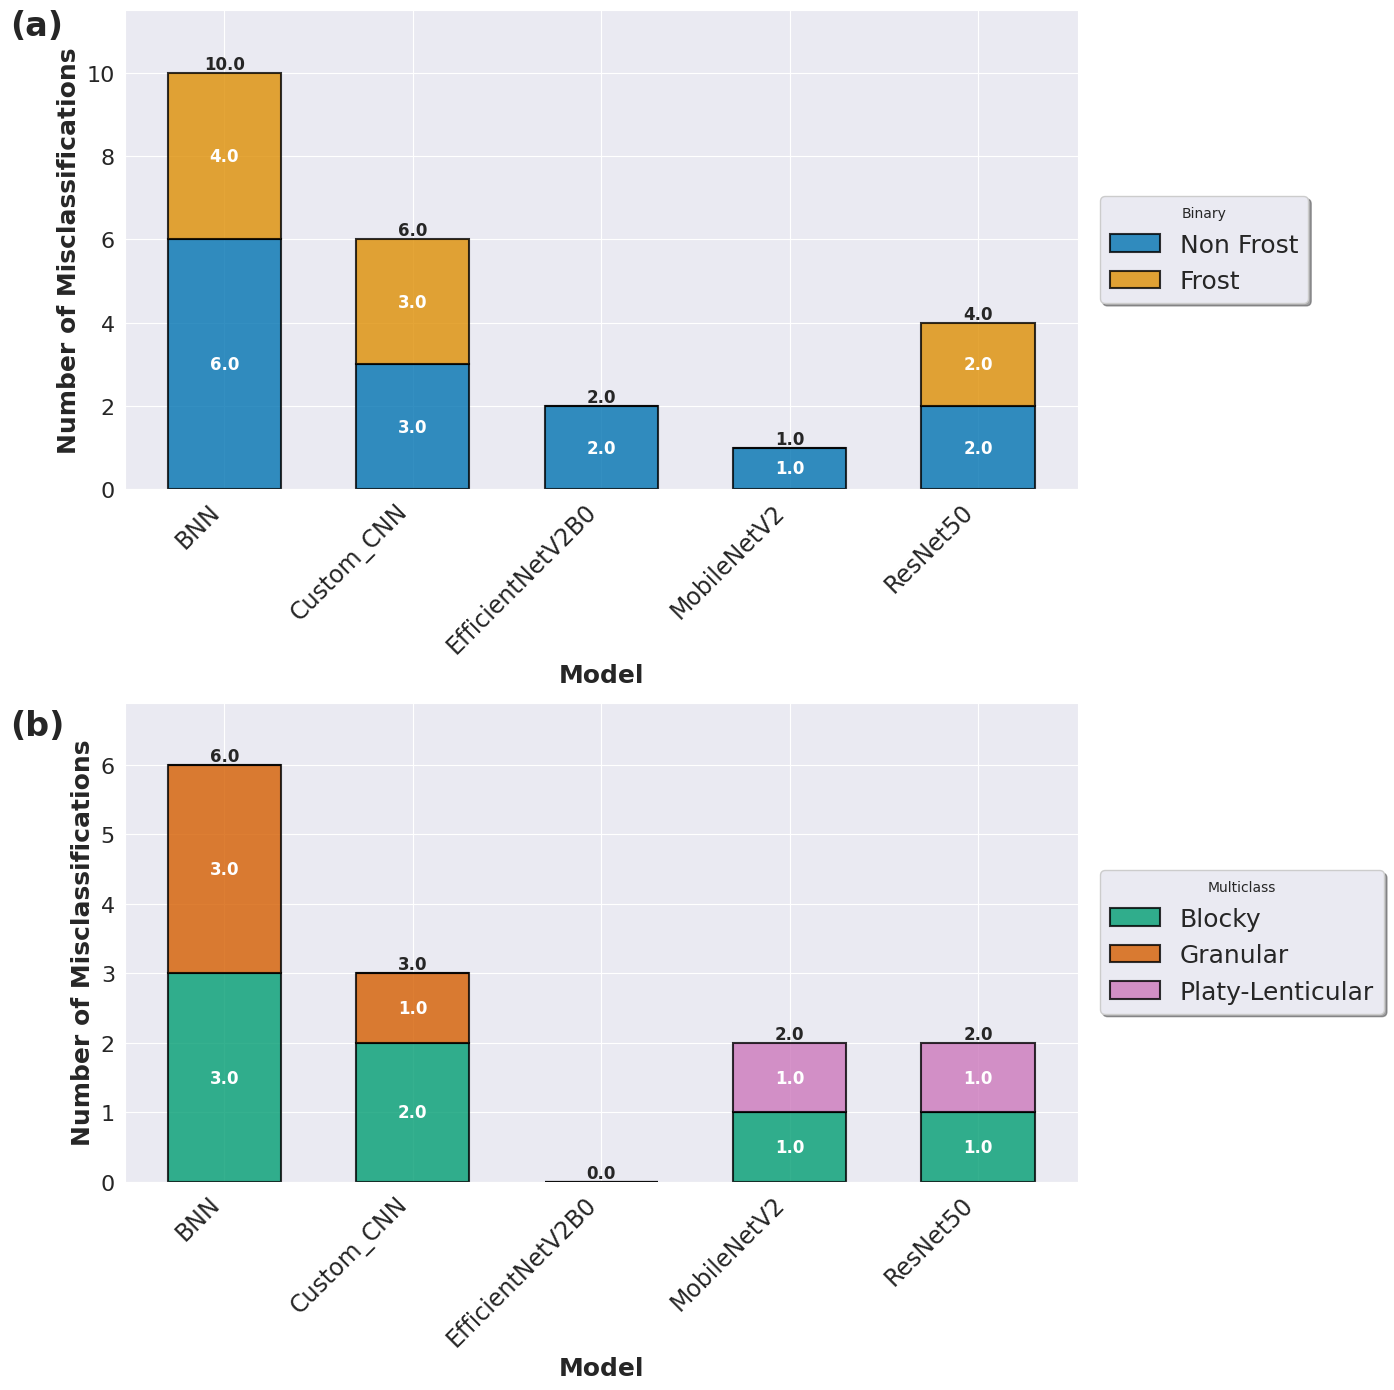

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains(r'_f\d', regex=True)].copy()

# Calculate misclassification statistics for binary - USING MEDIAN
stats_misclass_binary = df_binary_cv.groupby('Base_Model').agg({
    'Misclassification Non Frost': ['median'],
    'Misclassifications Frost': ['median']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains(r'_f\d', regex=True)].copy()

# Check what misclassification columns exist in multiclass data
print("Available columns in multiclass data:")
print([col for col in df_multi_cv.columns if 'isclass' in col.lower()])

# Calculate misclassification statistics for multiclass - USING MEDIAN
# Try with possible column name variations
try:
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassifications Blocky': ['median'],
        'Misclassifications Granular': ['median'],
        'Misclassifications Platy-Lenticular': ['median']
    })
except KeyError:
    # If that doesn't work, try without 's'
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassification Blocky': ['median'],
        'Misclassification Granular': ['median'],
        'Misclassification Platy-Lenticular': ['median']
    })

# ==========================================
# DEFINE CONSISTENT COLOR SCHEME
# ==========================================
colorblind_palette = sns.color_palette('colorblind')

# Assign a unique color to each class across both plots
color_non_frost = colorblind_palette[0]      # Blue
color_frost_binary = colorblind_palette[1]   # Orange
color_blocky = colorblind_palette[2]         # Green
color_granular = colorblind_palette[3]       # Red
color_platy = colorblind_palette[4]          # Purple

# ==========================================
# CREATE 2x1 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# ==========================================
# PLOT BINARY MISCLASSIFICATIONS (TOP)
# ==========================================
ax = axes[0]

x_binary = np.arange(len(stats_misclass_binary.index))

medians_non_frost = stats_misclass_binary['Misclassification Non Frost']['median']
medians_frost = stats_misclass_binary['Misclassifications Frost']['median']

# Create stacked bars with consistent colors
bars1 = ax.bar(x_binary, medians_non_frost, width=0.6, label='Non Frost',
               color=color_non_frost, edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_binary, medians_frost, width=0.6, bottom=medians_non_frost, label='Frost',
               color=color_frost_binary, edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
#ax.set_title('Median Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_binary)
ax.set_xticklabels(stats_misclass_binary.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(medians_non_frost + medians_frost) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_binary)):
    total = medians_non_frost.iloc[i] + medians_frost.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add legend for binary
handles_binary, labels_binary = ax.get_legend_handles_labels()
ax.legend(handles_binary, labels_binary,
          loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=18, frameon=True, shadow=True, markerscale=1.5,
          title='Binary')

# ==========================================
# PLOT MULTICLASS MISCLASSIFICATIONS (BOTTOM)
# ==========================================
ax = axes[1]

x_multi = np.arange(len(stats_misclass_multi.index))

# Get the first column name to determine if it's 'Misclassification' or 'Misclassifications'
first_col = list(stats_misclass_multi.columns.levels[0])[0]
col_prefix = 'Misclassifications' if first_col.startswith('Misclassifications') else 'Misclassification'

medians_blocky = stats_misclass_multi[first_col]['median']
medians_granular = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[1]]['median']
medians_platy = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[2]]['median']

# Create stacked bars with consistent colors
bars1 = ax.bar(x_multi, medians_blocky, width=0.6, label='Blocky',
               color=color_blocky, edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_multi, medians_granular, width=0.6, bottom=medians_blocky, label='Granular',
               color=color_granular, edgecolor='black', linewidth=1.5, alpha=0.8)
bars3 = ax.bar(x_multi, medians_platy, width=0.6, bottom=medians_blocky + medians_granular,
               label='Platy-Lenticular', color=color_platy, edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
#ax.set_title('Median Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_multi)
ax.set_xticklabels(stats_misclass_multi.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(medians_blocky + medians_granular + medians_platy) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_multi)):
    total = medians_blocky.iloc[i] + medians_granular.iloc[i] + medians_platy.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add legend for multiclass
handles_multi, labels_multi = ax.get_legend_handles_labels()
ax.legend(handles_multi, labels_multi,
          loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=18, frameon=True, shadow=True, markerscale=1.5,
          title='Multiclass')

# ==========================================
# ADD (a) and (b) LABELS OUTSIDE PLOTS
# ==========================================
# Add (a) label outside top plot - upper left
fig.text(0.01, 0.99, '(a)', fontsize=24, fontweight='bold', va='top', ha='left')

# Add (b) label outside bottom plot - upper left
fig.text(0.01, 0.49, '(b)', fontsize=24, fontweight='bold', va='top', ha='left')

# ==========================================
# ADJUST LAYOUT AND SAVE
# ==========================================
plt.tight_layout(rect=[0.03, 0, 0.88, 1])

# Save the figure
output_path = '/content/drive/My Drive/combined_misclassifications_stacked_median.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2902825001.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()
/tmp/ipython-input-2902825001.py:30: SyntaxWarning: invalid escape sequence '\d'
  df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/combined_classification_performance2.tif


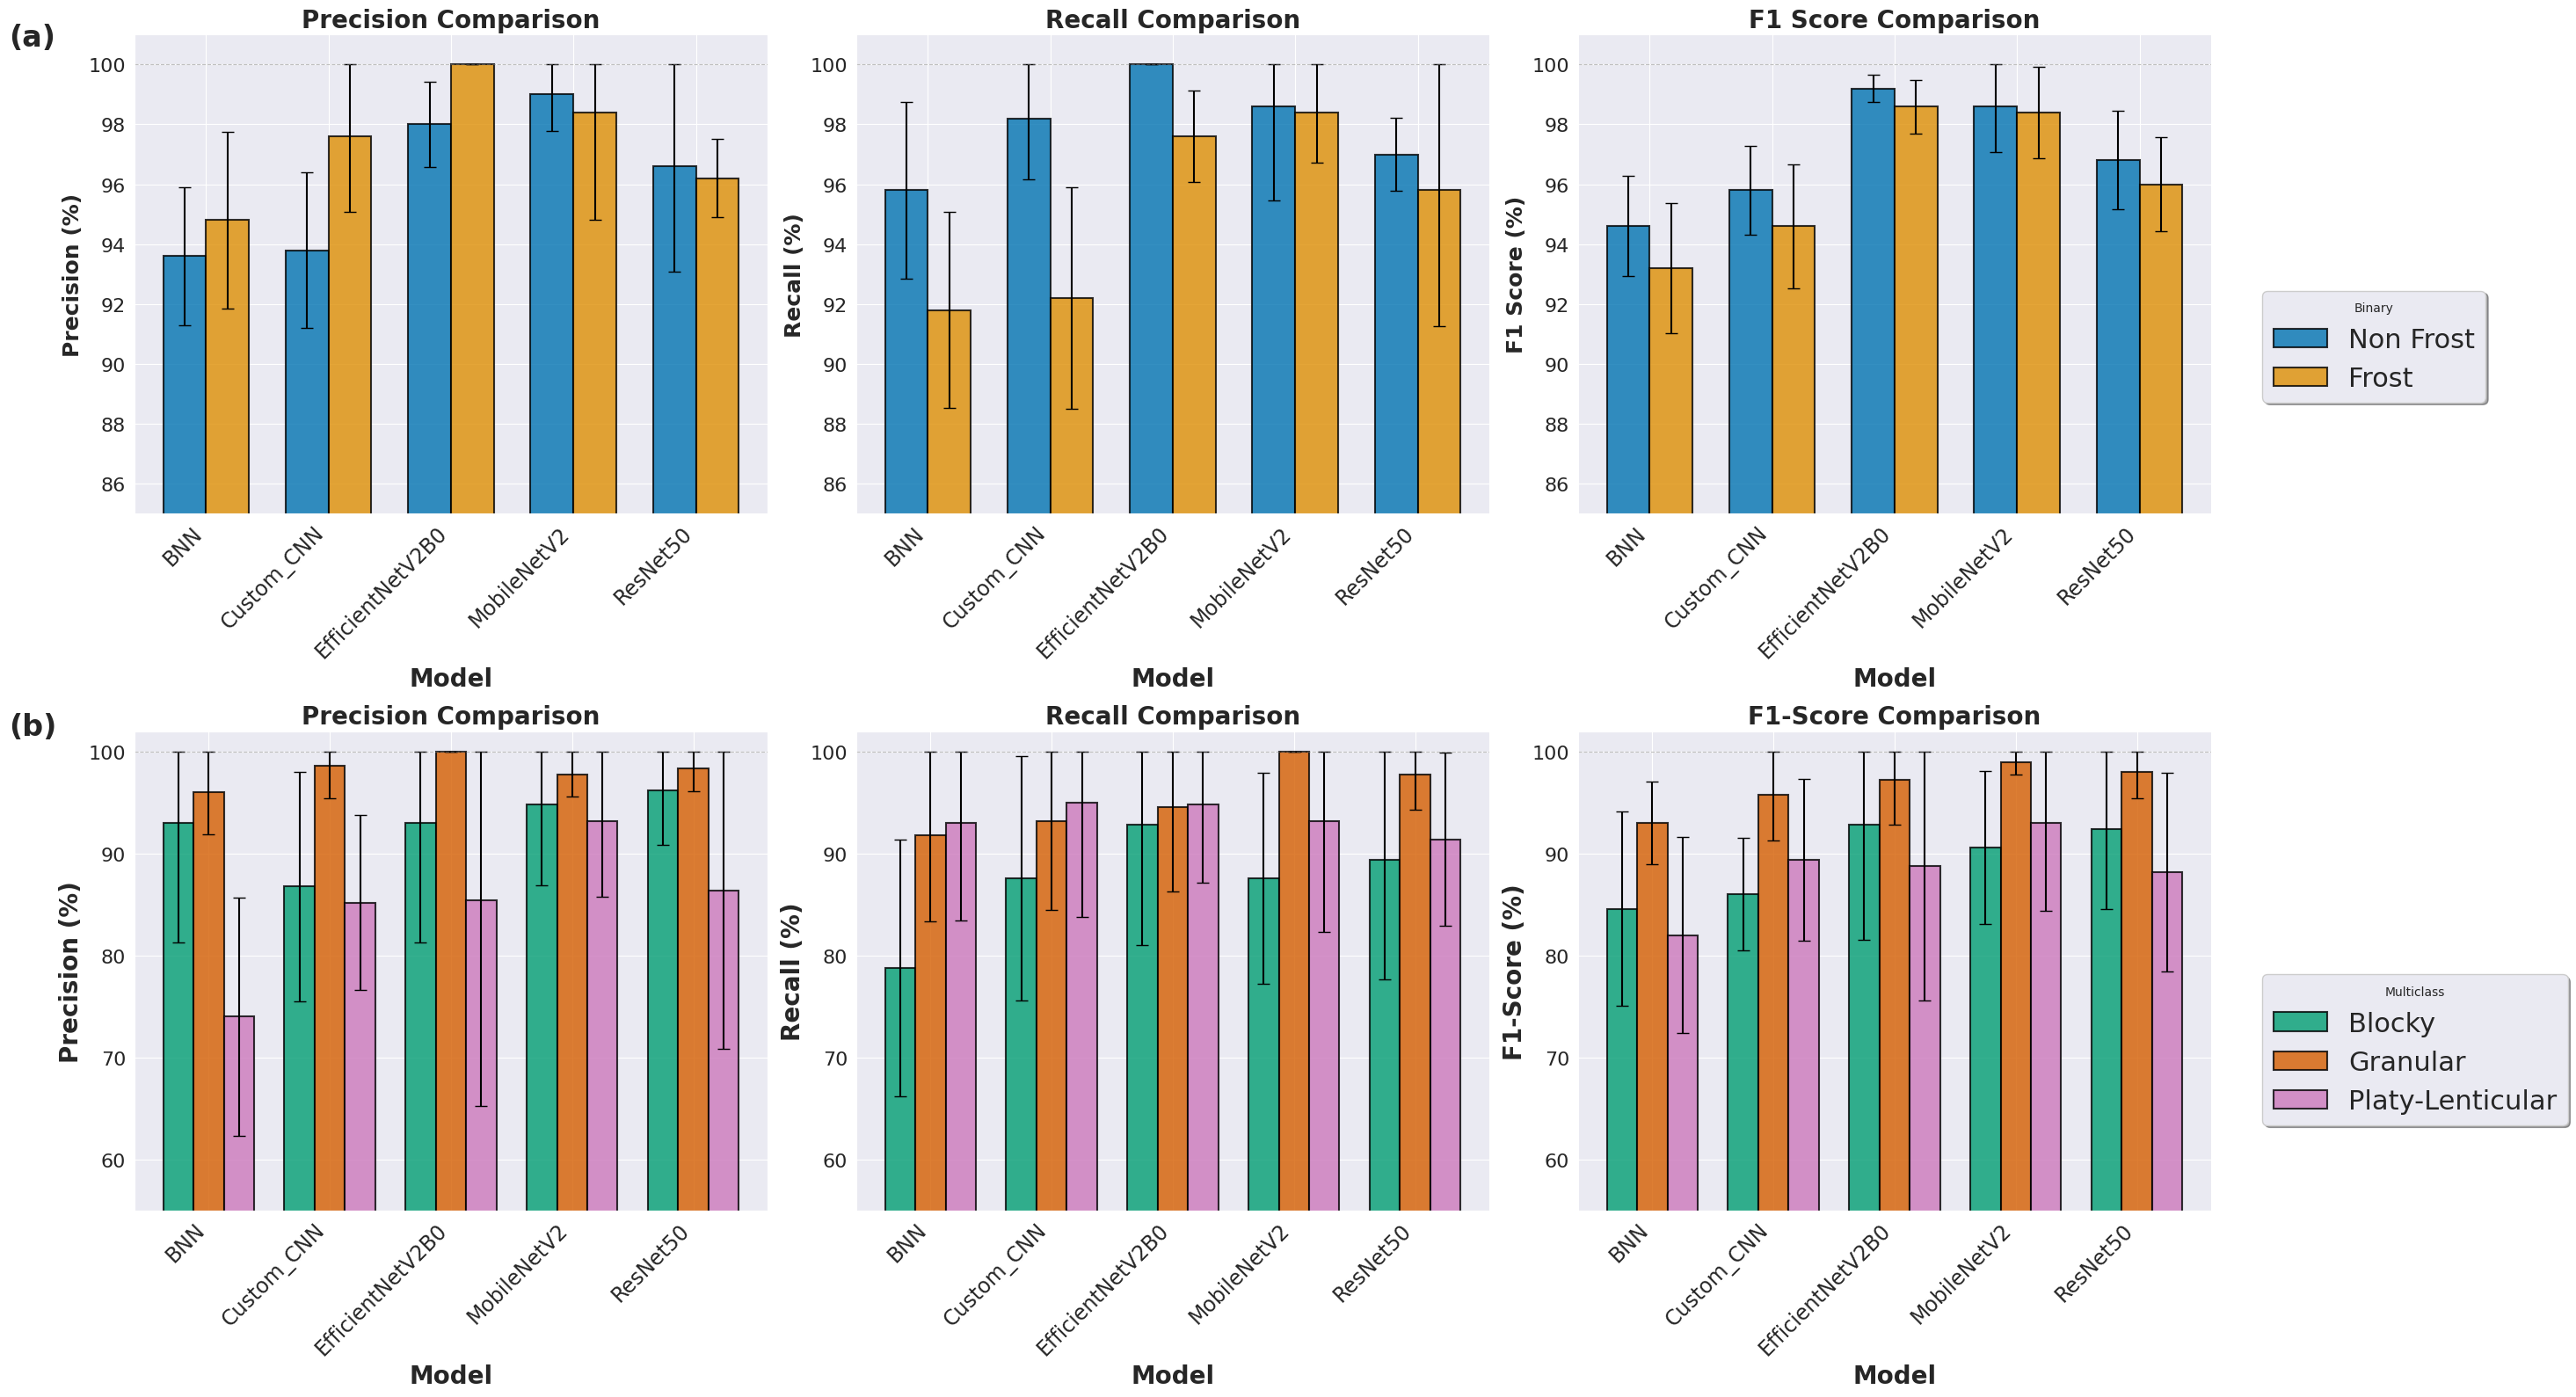

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()

stats_binary = df_binary_cv.groupby('Base_Model').agg({
    'Precision Non Frost': ['mean', 'std'],
    'Recall Non Frost': ['mean', 'std'],
    'F1 Score Non frost': ['mean', 'std'],
    'Precision Frost': ['mean', 'std'],
    'Recall Frost': ['mean', 'std'],
    'F1 Score Frost': ['mean', 'std']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()

stats_multi = df_multi_cv.groupby('Base_Model').agg({
    'Precision  Blocky': ['mean', 'std'],
    'Recall Blocky': ['mean', 'std'],
    'F1-Score Blocky': ['mean', 'std'],
    'Precision Granular': ['mean', 'std'],
    'Recall Granular': ['mean', 'std'],
    'F1-Score Granular': ['mean', 'std'],
    'Precision Platy-Lenticular': ['mean', 'std'],
    'Recall Platy-Lenticular': ['mean', 'std'],
    'F1-Score Platy-Lenticular': ['mean', 'std']
})

# ==========================================
# DEFINE CONSISTENT COLOR SCHEME
# ==========================================
colorblind_palette = sns.color_palette('colorblind')

# Assign a unique color to each class across both plots (matching previous figure)
color_non_frost = colorblind_palette[0]      # Blue
color_frost_binary = colorblind_palette[1]   # Orange
color_blocky = colorblind_palette[2]         # Green
color_granular = colorblind_palette[3]       # Red
color_platy = colorblind_palette[4]          # Purple

# ==========================================
# CREATE 2x3 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(28, 16))
plt.subplots_adjust(hspace=0.4)

# ==========================================
# PLOT BINARY CLASSIFICATION (TOP ROW)
# ==========================================
metrics_binary = [
    ('Precision', 'Precision Non Frost', 'Precision Frost'),
    ('Recall', 'Recall Non Frost', 'Recall Frost'),
    ('F1 Score', 'F1 Score Non frost', 'F1 Score Frost')
]

x_binary = np.arange(len(stats_binary.index))
width_binary = 0.35
colors_binary = [color_non_frost, color_frost_binary]  # Blue and Orange

for idx, (metric_name, non_frost_col, frost_col) in enumerate(metrics_binary):
    ax = axes[0, idx]  # First row

    # Get means and stds and convert to percentages
    means_non_frost = stats_binary[non_frost_col]['mean'] * 100
    stds_non_frost = stats_binary[non_frost_col]['std'] * 100
    means_frost = stats_binary[frost_col]['mean'] * 100
    stds_frost = stats_binary[frost_col]['std'] * 100

    # Calculate error bars
    upper_err_non_frost = np.minimum(stds_non_frost, 100 - means_non_frost)
    upper_err_frost = np.minimum(stds_frost, 100 - means_frost)
    lower_err_non_frost = stds_non_frost
    lower_err_frost = stds_frost

    errors_non_frost = [lower_err_non_frost, upper_err_non_frost]
    errors_frost = [lower_err_frost, upper_err_frost]

    # Create grouped bars
    bars1 = ax.bar(x_binary - width_binary/2, means_non_frost, width_binary, yerr=errors_non_frost,
                   capsize=5, label='Non Frost', color=colors_binary[0],
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2 = ax.bar(x_binary + width_binary/2, means_frost, width_binary, yerr=errors_frost,
                   capsize=5, label='Frost', color=colors_binary[1],
                   edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_binary)
    ax.set_xticklabels(stats_binary.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(85, 101)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT MULTICLASS CLASSIFICATION (BOTTOM ROW)
# ==========================================
metrics_multi = [
    ('Precision', 'Precision  Blocky', 'Precision Granular', 'Precision Platy-Lenticular'),
    ('Recall', 'Recall Blocky', 'Recall Granular', 'Recall Platy-Lenticular'),
    ('F1-Score', 'F1-Score Blocky', 'F1-Score Granular', 'F1-Score Platy-Lenticular')
]

x_multi = np.arange(len(stats_multi.index))
width_multi = 0.25
colors_multi = [color_blocky, color_granular, color_platy]  # Green, Red, Purple
class_names = ['Blocky', 'Granular', 'Platy-Lenticular']

for idx, (metric_name, blocky_col, granular_col, platy_col) in enumerate(metrics_multi):
    ax = axes[1, idx]  # Second row

    columns = [blocky_col, granular_col, platy_col]

    for class_idx, (col, class_name, color) in enumerate(zip(columns, class_names, colors_multi)):
        # Get means and stds and convert to percentages
        means = stats_multi[col]['mean'] * 100
        stds = stats_multi[col]['std'] * 100

        # Calculate error bars
        upper_err = np.minimum(stds, 100 - means)
        lower_err = stds
        errors = [lower_err, upper_err]

        # Position bars
        position = x_multi + width_multi * (class_idx - 1)

        # Create grouped bars
        bars = ax.bar(position, means, width_multi, yerr=errors,
                     capsize=5, label=class_name, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=20, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_multi)
    ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(55, 102)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# ADD (a) and (b) LABELS OUTSIDE PLOTS
# ==========================================
# Add (a) label outside top row - upper left
fig.text(0.01, 0.98, '(a)', fontsize=24, fontweight='bold', va='top', ha='left')

# Add (b) label outside bottom row - upper left
fig.text(0.01, 0.49, '(b)', fontsize=24, fontweight='bold', va='top', ha='left')

# ==========================================
# ADD LEGENDS ON THE RIGHT SIDE OF EACH ROW
# ==========================================
# Legend for binary (right side of top row)
handles_binary, labels_binary = axes[0, 0].get_legend_handles_labels()
legend_binary = fig.legend(handles_binary, labels_binary,
                          loc='center left', bbox_to_anchor=(0.92, 0.75),
                          fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                          title='Binary')

# Legend for multiclass (right side of bottom row)
handles_multi, labels_multi = axes[1, 0].get_legend_handles_labels()
legend_multi = fig.legend(handles_multi, labels_multi,
                         loc='center left', bbox_to_anchor=(0.92, 0.25),
                         fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                         title='Multiclass')

plt.tight_layout(rect=[0.025, 0, 0.91, 1])  # Leave space on the right for legends

# Save the figure
output_path = '/content/drive/My Drive/combined_classification_performance2.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

Figure saved to: /content/drive/My Drive/learning_dynamics_combined_5points.tif


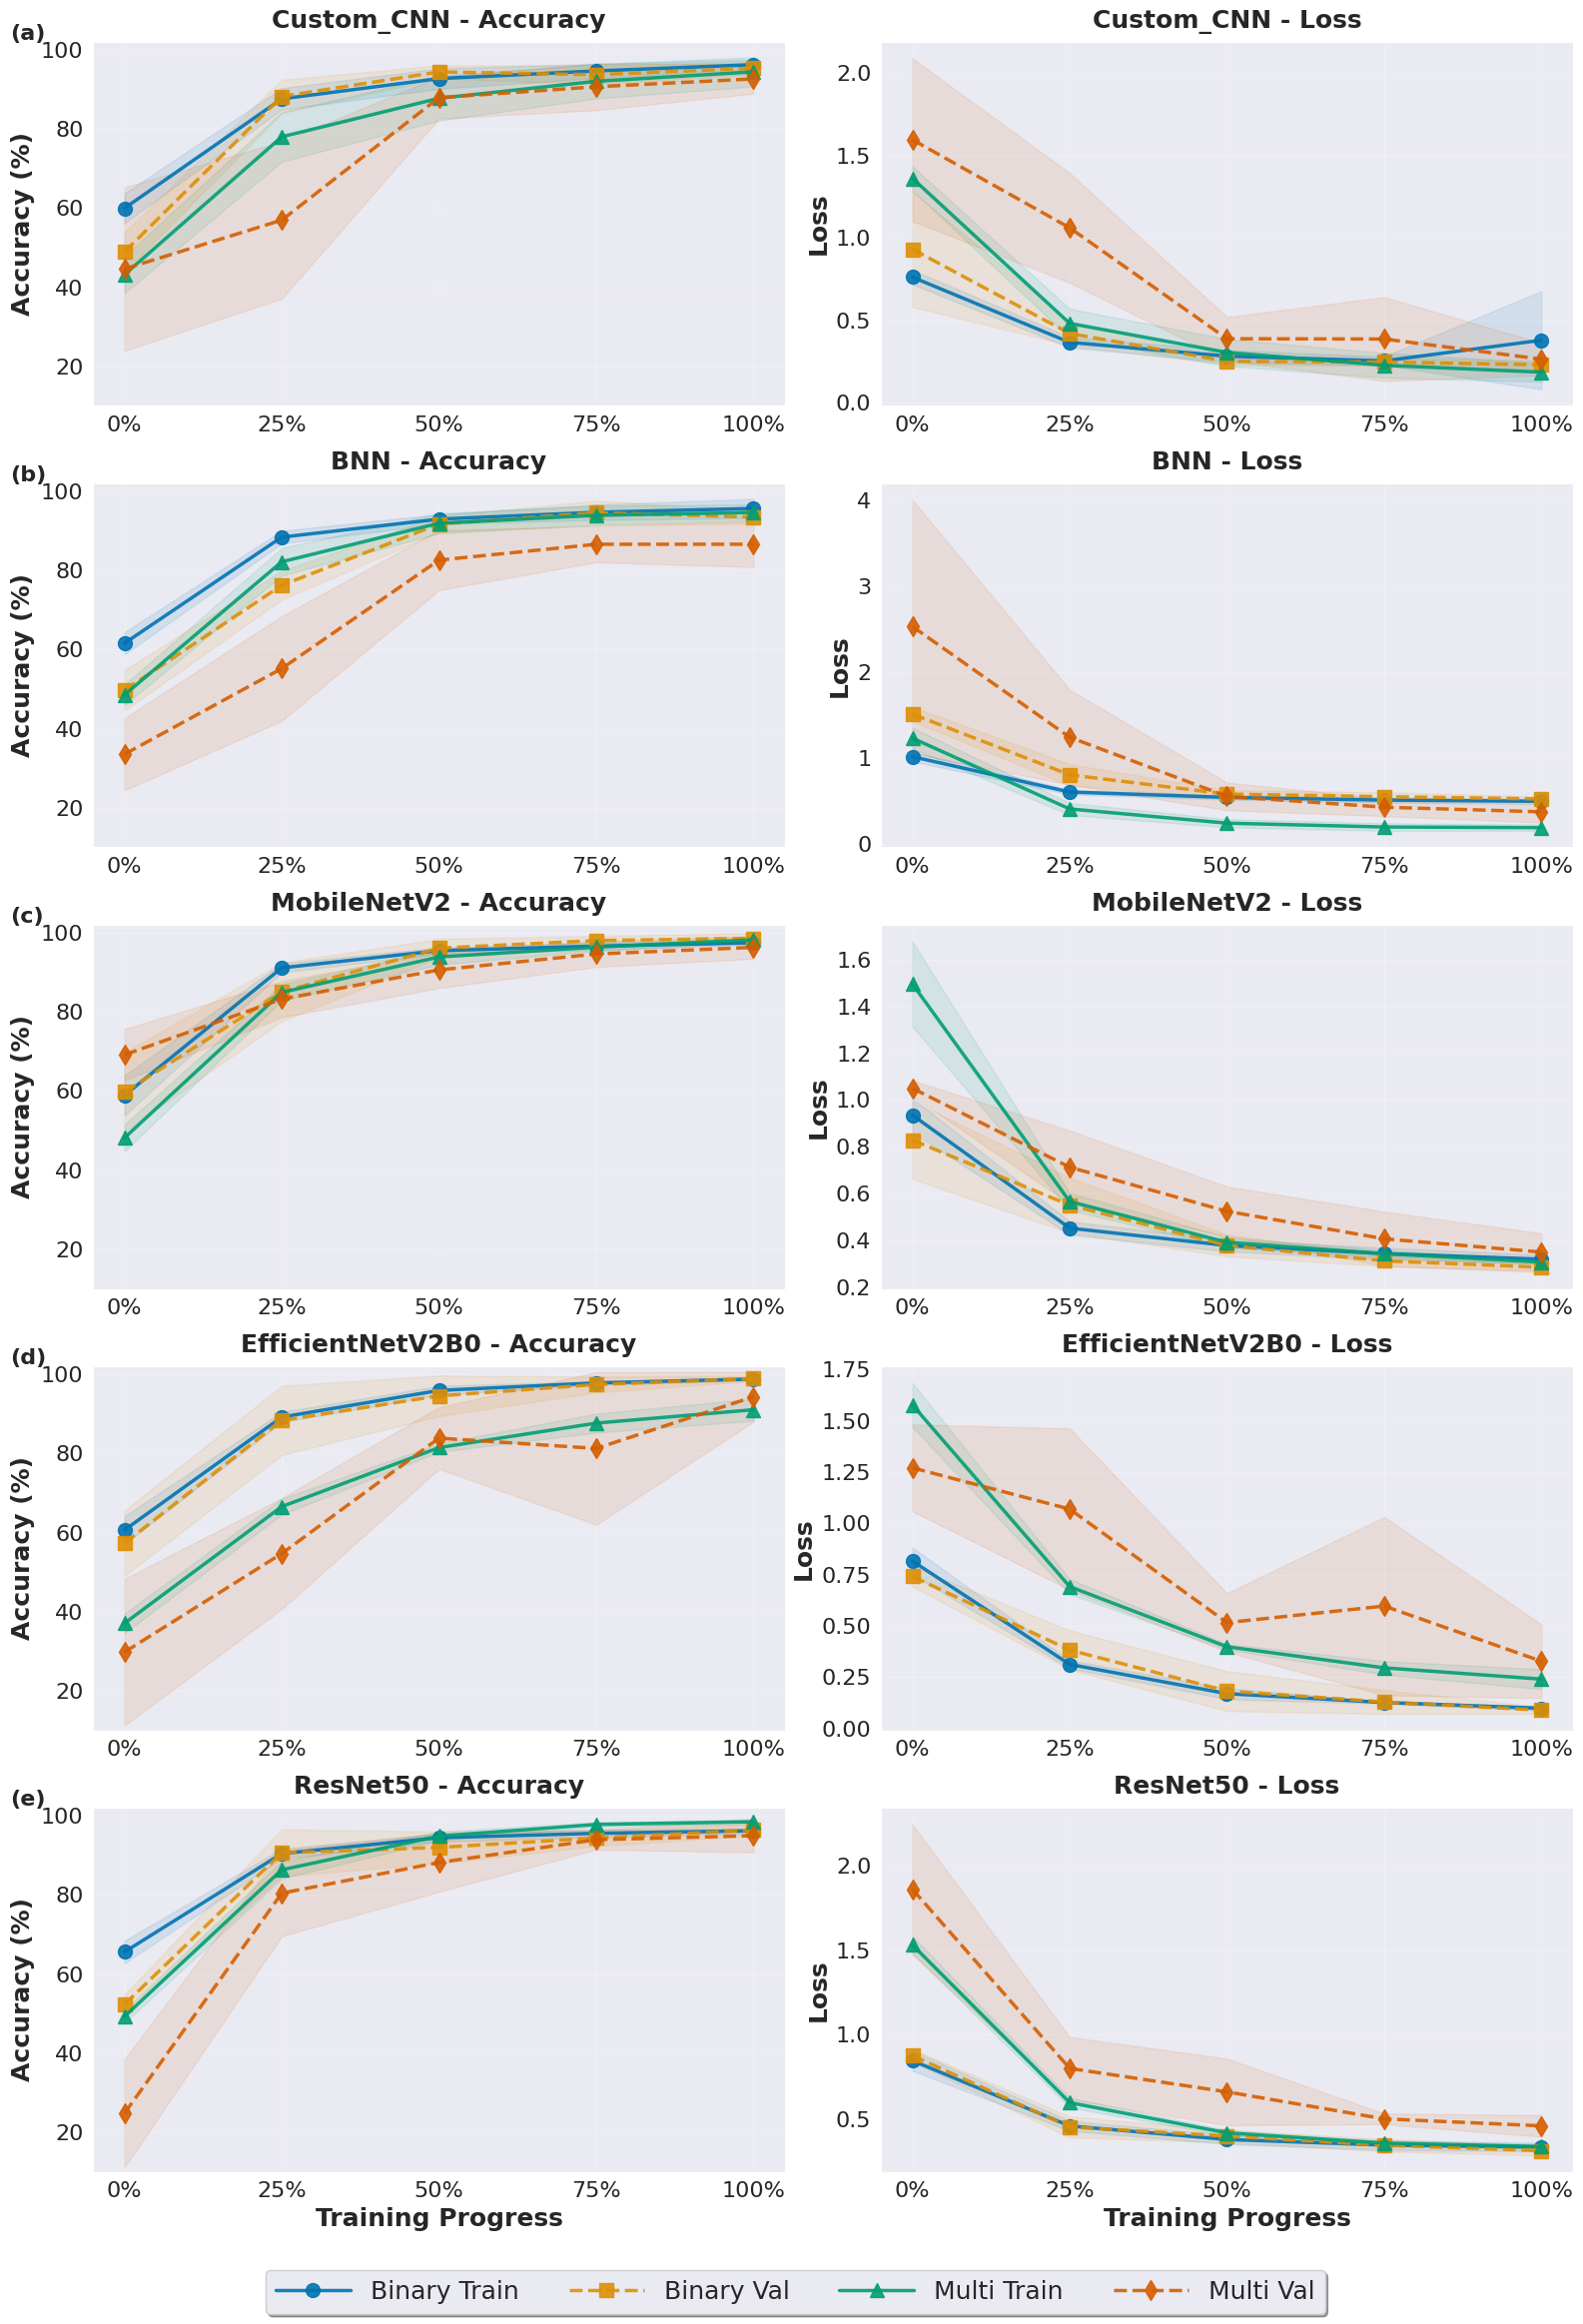

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

# Set seaborn style
sns.set_style('darkgrid')

# Read both binary and multiclass data
df_binary = pd.read_excel(file_path, sheet_name='training_dynamics_binary')
df_multiclass = pd.read_excel(file_path, sheet_name='training_dynamics_multiclass')

# Set the first column as index
df_binary = df_binary.set_index(df_binary.columns[0])
df_multiclass = df_multiclass.set_index(df_multiclass.columns[0])

# Extract model columns for both tasks
binary_columns = [col for col in df_binary.columns if '_f' in col]
multiclass_columns = [col for col in df_multiclass.columns if '_f' in col]

# Function to organize data by model
def organize_data(df, columns):
    models_data = {}
    for col in columns:
        base_model = col.rsplit('_f', 1)[0]
        if base_model not in models_data:
            models_data[base_model] = {
                'train_acc_initial': [], 'train_acc_25': [], 'train_acc_middle': [],
                'train_acc_75': [], 'train_acc_final': [],
                'val_acc_initial': [], 'val_acc_25': [], 'val_acc_middle': [],
                'val_acc_75': [], 'val_acc_final': [],
                'train_loss_initial': [], 'train_loss_25': [], 'train_loss_middle': [],
                'train_loss_75': [], 'train_loss_final': [],
                'val_loss_initial': [], 'val_loss_25': [], 'val_loss_middle': [],
                'val_loss_75': [], 'val_loss_final': []
            }

        models_data[base_model]['train_acc_initial'].append(df.loc['Training_intitial_accuracy', col])
        models_data[base_model]['train_acc_25'].append(df.loc['Training_25_accuracy', col])
        models_data[base_model]['train_acc_middle'].append(df.loc['Training_middle_accuracy', col])
        models_data[base_model]['train_acc_75'].append(df.loc['Training_75_accuracy', col])
        models_data[base_model]['train_acc_final'].append(df.loc['Training_final_accuracy', col])

        models_data[base_model]['val_acc_initial'].append(df.loc['Validation_initial_accuracy', col])
        models_data[base_model]['val_acc_25'].append(df.loc['Validation_25_accuracy', col])
        models_data[base_model]['val_acc_middle'].append(df.loc['Validation_middle_accuracy', col])
        models_data[base_model]['val_acc_75'].append(df.loc['Validation_75_accuracy', col])
        models_data[base_model]['val_acc_final'].append(df.loc['Validation_final_accuracy', col])

        models_data[base_model]['train_loss_initial'].append(df.loc['Training_intitial_loss', col])
        models_data[base_model]['train_loss_25'].append(df.loc['Training_25_loss', col])
        models_data[base_model]['train_loss_middle'].append(df.loc['Training_middle_loss', col])
        models_data[base_model]['train_loss_75'].append(df.loc['Training_75_loss', col])
        models_data[base_model]['train_loss_final'].append(df.loc['Training_final_loss', col])

        models_data[base_model]['val_loss_initial'].append(df.loc['Validation_initial_loss', col])
        models_data[base_model]['val_loss_25'].append(df.loc['Validation_25_loss', col])
        models_data[base_model]['val_loss_middle'].append(df.loc['Validation_middle_loss', col])
        models_data[base_model]['val_loss_75'].append(df.loc['Validation_75_loss', col])
        models_data[base_model]['val_loss_final'].append(df.loc['Validation_final_loss', col])

    return models_data

# Organize data for both tasks
binary_data = organize_data(df_binary, binary_columns)
multiclass_data = organize_data(df_multiclass, multiclass_columns)

# Calculate statistics
def calculate_stats(models_data):
    stats = {}
    for model, data in models_data.items():
        stats[model] = {}
        for key, values in data.items():
            stats[model][key] = {'mean': np.mean(values), 'std': np.std(values)}
    return stats

stats_binary = calculate_stats(binary_data)
stats_multiclass = calculate_stats(multiclass_data)

# Time points - now 5 points
time_points = [0, 1, 2, 3, 4]
time_labels = ['0%', '25%', '50%', '75%', '100%']

model_names = list(stats_binary.keys())
n_models = len(model_names)

# Create figure with 2 columns (Accuracy, Loss) and n_models rows
# Add extra space at bottom for shared legend
fig, axes = plt.subplots(n_models, 2, figsize=(16, 4.5*n_models + 0.5))
if n_models == 1:
    axes = axes.reshape(1, -1)

# Generate subplot labels
subplot_labels = list(string.ascii_lowercase)

# Color scheme
colors = {
    'binary_train': '#0173B2',
    'binary_val': '#DE8F05',
    'multiclass_train': '#029E73',
    'multiclass_val': '#D55E00'
}

for idx, model in enumerate(model_names):
    # LEFT: ACCURACY
    ax_acc = axes[idx, 0]

    # Binary Train - 5 points
    train_acc_means_bin = [
        stats_binary[model]['train_acc_initial']['mean'] * 100,
        stats_binary[model]['train_acc_25']['mean'] * 100,
        stats_binary[model]['train_acc_middle']['mean'] * 100,
        stats_binary[model]['train_acc_75']['mean'] * 100,
        stats_binary[model]['train_acc_final']['mean'] * 100
    ]
    train_acc_stds_bin = [
        stats_binary[model]['train_acc_initial']['std'] * 100,
        stats_binary[model]['train_acc_25']['std'] * 100,
        stats_binary[model]['train_acc_middle']['std'] * 100,
        stats_binary[model]['train_acc_75']['std'] * 100,
        stats_binary[model]['train_acc_final']['std'] * 100
    ]

    # Binary Val - 5 points
    val_acc_means_bin = [
        stats_binary[model]['val_acc_initial']['mean'] * 100,
        stats_binary[model]['val_acc_25']['mean'] * 100,
        stats_binary[model]['val_acc_middle']['mean'] * 100,
        stats_binary[model]['val_acc_75']['mean'] * 100,
        stats_binary[model]['val_acc_final']['mean'] * 100
    ]
    val_acc_stds_bin = [
        stats_binary[model]['val_acc_initial']['std'] * 100,
        stats_binary[model]['val_acc_25']['std'] * 100,
        stats_binary[model]['val_acc_middle']['std'] * 100,
        stats_binary[model]['val_acc_75']['std'] * 100,
        stats_binary[model]['val_acc_final']['std'] * 100
    ]

    # Multiclass Train - 5 points
    train_acc_means_multi = [
        stats_multiclass[model]['train_acc_initial']['mean'] * 100,
        stats_multiclass[model]['train_acc_25']['mean'] * 100,
        stats_multiclass[model]['train_acc_middle']['mean'] * 100,
        stats_multiclass[model]['train_acc_75']['mean'] * 100,
        stats_multiclass[model]['train_acc_final']['mean'] * 100
    ]
    train_acc_stds_multi = [
        stats_multiclass[model]['train_acc_initial']['std'] * 100,
        stats_multiclass[model]['train_acc_25']['std'] * 100,
        stats_multiclass[model]['train_acc_middle']['std'] * 100,
        stats_multiclass[model]['train_acc_75']['std'] * 100,
        stats_multiclass[model]['train_acc_final']['std'] * 100
    ]

    # Multiclass Val - 5 points
    val_acc_means_multi = [
        stats_multiclass[model]['val_acc_initial']['mean'] * 100,
        stats_multiclass[model]['val_acc_25']['mean'] * 100,
        stats_multiclass[model]['val_acc_middle']['mean'] * 100,
        stats_multiclass[model]['val_acc_75']['mean'] * 100,
        stats_multiclass[model]['val_acc_final']['mean'] * 100
    ]
    val_acc_stds_multi = [
        stats_multiclass[model]['val_acc_initial']['std'] * 100,
        stats_multiclass[model]['val_acc_25']['std'] * 100,
        stats_multiclass[model]['val_acc_middle']['std'] * 100,
        stats_multiclass[model]['val_acc_75']['std'] * 100,
        stats_multiclass[model]['val_acc_final']['std'] * 100
    ]

    # Plot Binary
    ax_acc.plot(time_points, train_acc_means_bin, '-o', color=colors['binary_train'],
                linewidth=2.5, markersize=10, label='Binary Train', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(train_acc_means_bin) - np.array(train_acc_stds_bin),
                        np.array(train_acc_means_bin) + np.array(train_acc_stds_bin),
                        color=colors['binary_train'], alpha=0.10)

    ax_acc.plot(time_points, val_acc_means_bin, '--s', color=colors['binary_val'],
                linewidth=2.5, markersize=10, label='Binary Val', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(val_acc_means_bin) - np.array(val_acc_stds_bin),
                        np.array(val_acc_means_bin) + np.array(val_acc_stds_bin),
                        color=colors['binary_val'], alpha=0.10)

    # Plot Multiclass
    ax_acc.plot(time_points, train_acc_means_multi, '-^', color=colors['multiclass_train'],
                linewidth=2.5, markersize=10, label='Multi Train', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(train_acc_means_multi) - np.array(train_acc_stds_multi),
                        np.array(train_acc_means_multi) + np.array(train_acc_stds_multi),
                        color=colors['multiclass_train'], alpha=0.10)

    ax_acc.plot(time_points, val_acc_means_multi, '--d', color=colors['multiclass_val'],
                linewidth=2.5, markersize=10, label='Multi Val', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(val_acc_means_multi) - np.array(val_acc_stds_multi),
                        np.array(val_acc_means_multi) + np.array(val_acc_stds_multi),
                        color=colors['multiclass_val'], alpha=0.10)

    ax_acc.set_ylabel('Accuracy (%)', fontsize=18, fontweight='bold')
    ax_acc.set_title(f'{model} - Accuracy', fontsize=18, fontweight='bold', pad=10)
    ax_acc.set_xticks(time_points)
    ax_acc.set_xticklabels(time_labels, fontsize=16)
    ax_acc.set_ylim(10, 102)
    ax_acc.tick_params(axis='y', labelsize=16)
    ax_acc.grid(True, alpha=0.2)

    # Add subplot label
    ax_acc.text(-0.12, 1.05, f'({subplot_labels[idx]})', transform=ax_acc.transAxes,
                fontsize=16, fontweight='bold', va='top')

    # RIGHT: LOSS
    ax_loss = axes[idx, 1]

    # Binary Train Loss - 5 points
    train_loss_means_bin = [
        stats_binary[model]['train_loss_initial']['mean'],
        stats_binary[model]['train_loss_25']['mean'],
        stats_binary[model]['train_loss_middle']['mean'],
        stats_binary[model]['train_loss_75']['mean'],
        stats_binary[model]['train_loss_final']['mean']
    ]
    train_loss_stds_bin = [
        stats_binary[model]['train_loss_initial']['std'],
        stats_binary[model]['train_loss_25']['std'],
        stats_binary[model]['train_loss_middle']['std'],
        stats_binary[model]['train_loss_75']['std'],
        stats_binary[model]['train_loss_final']['std']
    ]

    # Binary Val Loss - 5 points
    val_loss_means_bin = [
        stats_binary[model]['val_loss_initial']['mean'],
        stats_binary[model]['val_loss_25']['mean'],
        stats_binary[model]['val_loss_middle']['mean'],
        stats_binary[model]['val_loss_75']['mean'],
        stats_binary[model]['val_loss_final']['mean']
    ]
    val_loss_stds_bin = [
        stats_binary[model]['val_loss_initial']['std'],
        stats_binary[model]['val_loss_25']['std'],
        stats_binary[model]['val_loss_middle']['std'],
        stats_binary[model]['val_loss_75']['std'],
        stats_binary[model]['val_loss_final']['std']
    ]

    # Multiclass Train Loss - 5 points
    train_loss_means_multi = [
        stats_multiclass[model]['train_loss_initial']['mean'],
        stats_multiclass[model]['train_loss_25']['mean'],
        stats_multiclass[model]['train_loss_middle']['mean'],
        stats_multiclass[model]['train_loss_75']['mean'],
        stats_multiclass[model]['train_loss_final']['mean']
    ]
    train_loss_stds_multi = [
        stats_multiclass[model]['train_loss_initial']['std'],
        stats_multiclass[model]['train_loss_25']['std'],
        stats_multiclass[model]['train_loss_middle']['std'],
        stats_multiclass[model]['train_loss_75']['std'],
        stats_multiclass[model]['train_loss_final']['std']
    ]

    # Multiclass Val Loss - 5 points
    val_loss_means_multi = [
        stats_multiclass[model]['val_loss_initial']['mean'],
        stats_multiclass[model]['val_loss_25']['mean'],
        stats_multiclass[model]['val_loss_middle']['mean'],
        stats_multiclass[model]['val_loss_75']['mean'],
        stats_multiclass[model]['val_loss_final']['mean']
    ]
    val_loss_stds_multi = [
        stats_multiclass[model]['val_loss_initial']['std'],
        stats_multiclass[model]['val_loss_25']['std'],
        stats_multiclass[model]['val_loss_middle']['std'],
        stats_multiclass[model]['val_loss_75']['std'],
        stats_multiclass[model]['val_loss_final']['std']
    ]

    # Plot Binary Loss
    ax_loss.plot(time_points, train_loss_means_bin, '-o', color=colors['binary_train'],
                 linewidth=2.5, markersize=10, label='Binary Train', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(train_loss_means_bin) - np.array(train_loss_stds_bin),
                         np.array(train_loss_means_bin) + np.array(train_loss_stds_bin),
                         color=colors['binary_train'], alpha=0.10)

    ax_loss.plot(time_points, val_loss_means_bin, '--s', color=colors['binary_val'],
                 linewidth=2.5, markersize=10, label='Binary Val', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(val_loss_means_bin) - np.array(val_loss_stds_bin),
                         np.array(val_loss_means_bin) + np.array(val_loss_stds_bin),
                         color=colors['binary_val'], alpha=0.10)

    # Plot Multiclass Loss
    ax_loss.plot(time_points, train_loss_means_multi, '-^', color=colors['multiclass_train'],
                 linewidth=2.5, markersize=10, label='Multi Train', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(train_loss_means_multi) - np.array(train_loss_stds_multi),
                         np.array(train_loss_means_multi) + np.array(train_loss_stds_multi),
                         color=colors['multiclass_train'], alpha=0.10)

    ax_loss.plot(time_points, val_loss_means_multi, '--d', color=colors['multiclass_val'],
                 linewidth=2.5, markersize=10, label='Multi Val', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(val_loss_means_multi) - np.array(val_loss_stds_multi),
                         np.array(val_loss_means_multi) + np.array(val_loss_stds_multi),
                         color=colors['multiclass_val'], alpha=0.10)

    ax_loss.set_ylabel('Loss', fontsize=18, fontweight='bold')
    ax_loss.set_title(f'{model} - Loss', fontsize=18, fontweight='bold', pad=10)
    ax_loss.set_xticks(time_points)
    ax_loss.set_xticklabels(time_labels, fontsize=16)
    ax_loss.tick_params(axis='y', labelsize=16)
    ax_loss.grid(True, alpha=0.2)

    # Only add xlabel to bottom row
    if idx == n_models - 1:
        ax_acc.set_xlabel('Training Progress', fontsize=18, fontweight='bold')
        ax_loss.set_xlabel('Training Progress', fontsize=18, fontweight='bold')

# Create one shared legend at the bottom center
# Get handles and labels from any subplot (they're all the same)
handles, labels = axes[0, 0].get_legend_handles_labels()

# Add single shared legend centered at bottom
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.015),
           fontsize=18, frameon=True, shadow=True, ncol=4, handlelength=3.0)

plt.tight_layout(rect=[0, 0.02, 1, 1])  # Leave space at bottom for legend

output_path = '/content/drive/My Drive/learning_dynamics_combined_5points.tif'
plt.savefig(output_path, dpi=400, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-860905740.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()
/tmp/ipython-input-860905740.py:35: SyntaxWarning: invalid escape sequence '\d'
  df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/2combined_classification_performance_with_accuracy.tif


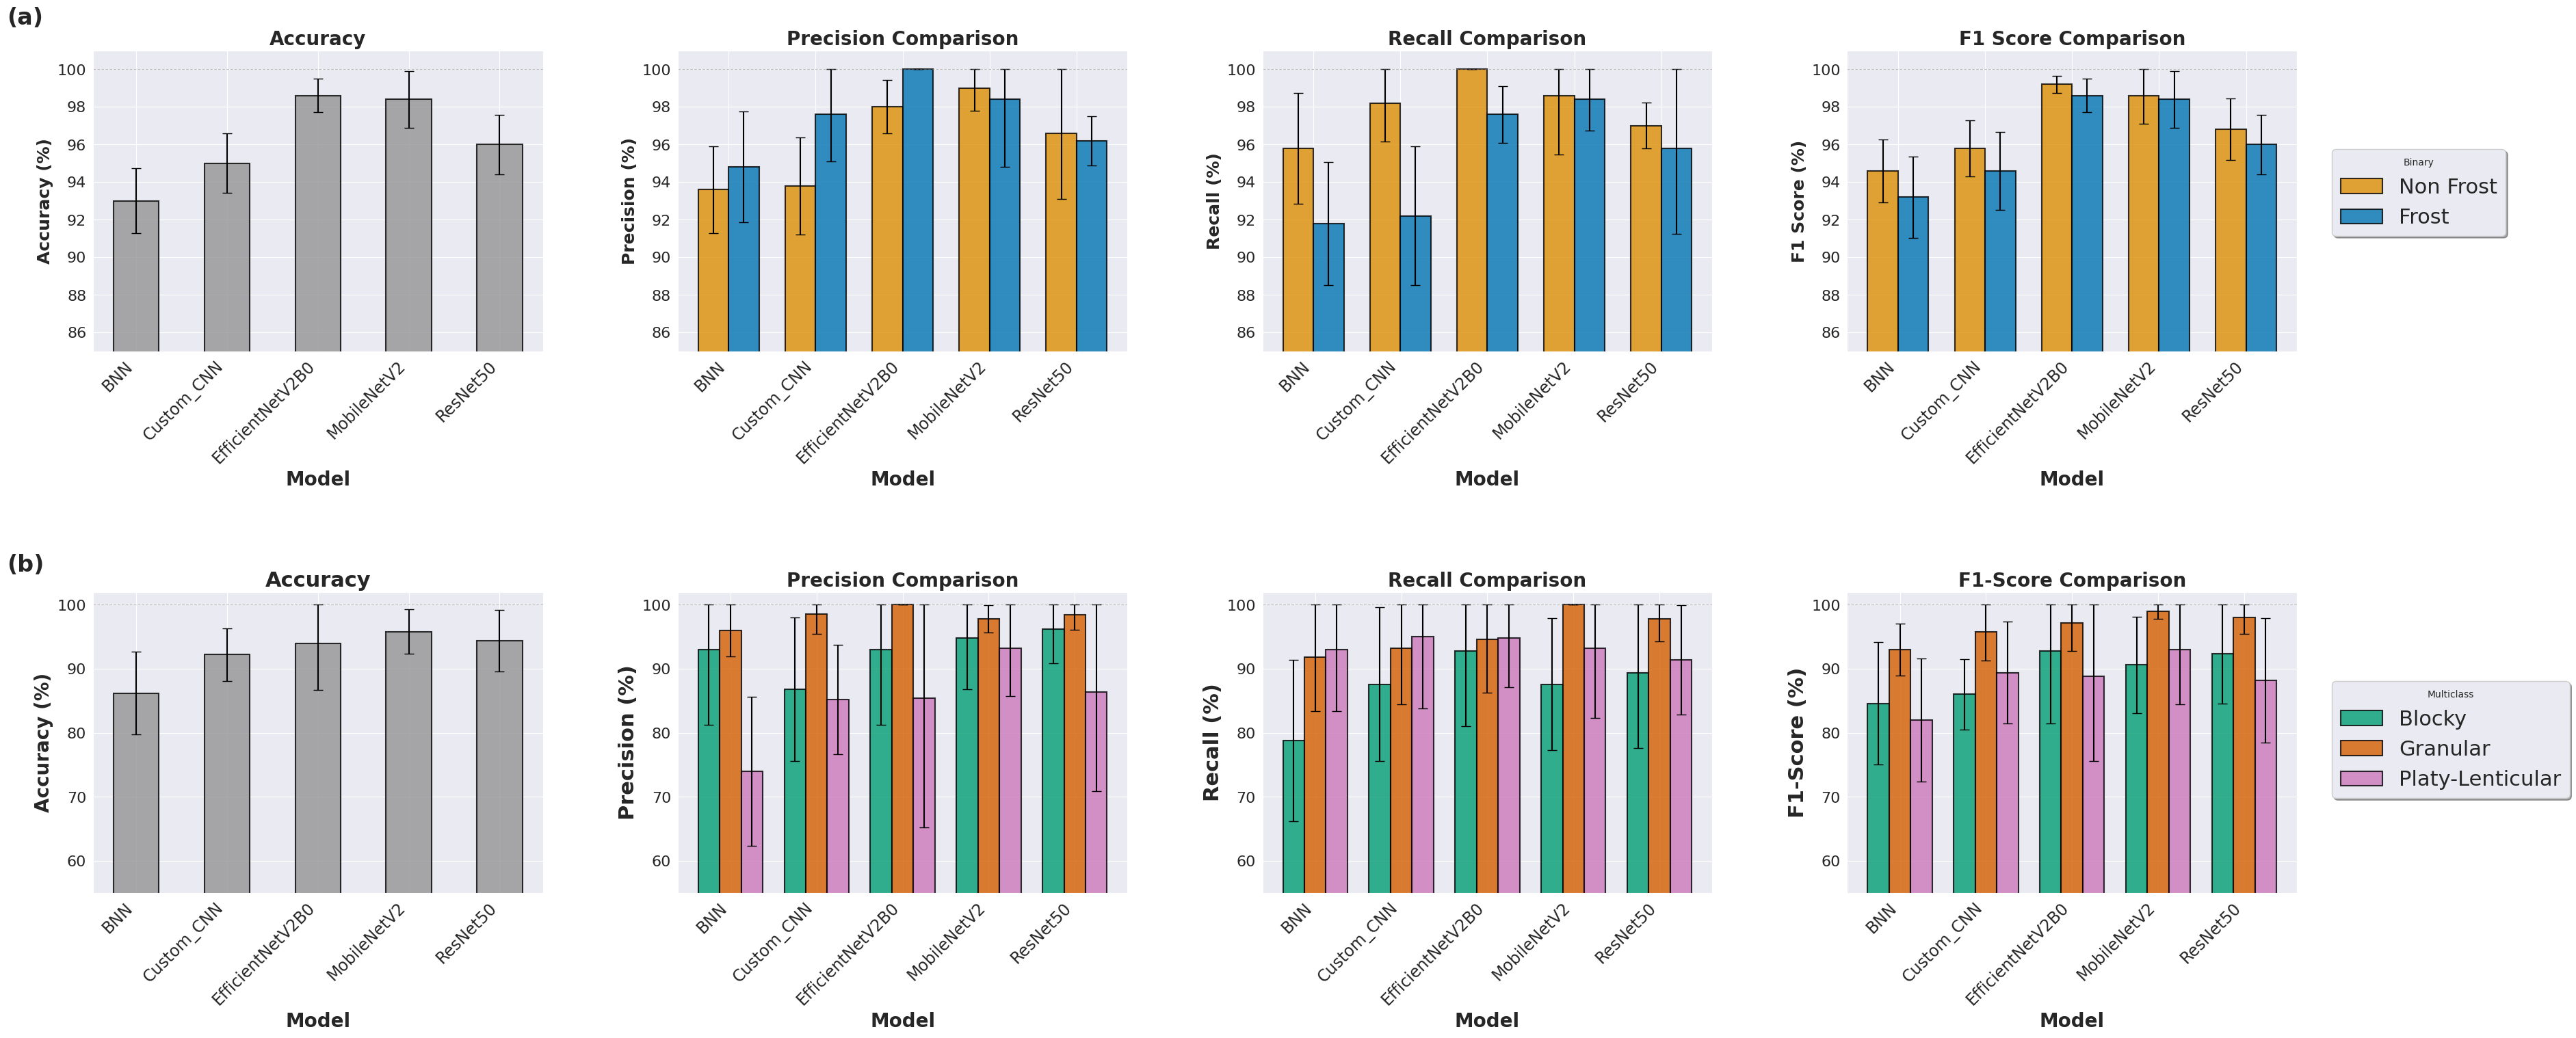

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()

# TODO: Check your actual column name for accuracy — it might be
# 'Accuracy', 'Val Accuracy', 'Validation Accuracy', etc.
# Print columns to verify: print(df_binary_cv.columns.tolist())

stats_binary = df_binary_cv.groupby('Base_Model').agg({
    'Accuracy': ['mean', 'std'],  # <-- adjust column name if needed
    'Precision Non Frost': ['mean', 'std'],
    'Recall Non Frost': ['mean', 'std'],
    'F1 Score Non frost': ['mean', 'std'],
    'Precision Frost': ['mean', 'std'],
    'Recall Frost': ['mean', 'std'],
    'F1 Score Frost': ['mean', 'std']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()

stats_multi = df_multi_cv.groupby('Base_Model').agg({
    'Accuracy': ['mean', 'std'],  # <-- adjust column name if needed
    'Precision  Blocky': ['mean', 'std'],
    'Recall Blocky': ['mean', 'std'],
    'F1-Score Blocky': ['mean', 'std'],
    'Precision Granular': ['mean', 'std'],
    'Recall Granular': ['mean', 'std'],
    'F1-Score Granular': ['mean', 'std'],
    'Precision Platy-Lenticular': ['mean', 'std'],
    'Recall Platy-Lenticular': ['mean', 'std'],
    'F1-Score Platy-Lenticular': ['mean', 'std']
})

# ==========================================
# DEFINE CONSISTENT COLOR SCHEME
# ==========================================
colorblind_palette = sns.color_palette('colorblind')

color_non_frost = colorblind_palette[1]      # Blue
color_frost_binary = colorblind_palette[0]   # Orange
color_blocky = colorblind_palette[2]         # Green
color_granular = colorblind_palette[3]       # Red
color_platy = colorblind_palette[4]          # Purple
color_accuracy = colorblind_palette[7]       # Gray — neutral for overall metric

# ==========================================
# CREATE 2x4 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(36, 16))
#plt.subplots_adjust(hspace=1.2)

# ==========================================
# PLOT BINARY ACCURACY (TOP ROW, FIRST COLUMN)
# ==========================================
ax = axes[0, 0]
x_binary = np.arange(len(stats_binary.index))

means_acc = stats_binary['Accuracy']['mean'] * 100
stds_acc = stats_binary['Accuracy']['std'] * 100
upper_err_acc = np.minimum(stds_acc, 100 - means_acc)
errors_acc = [stds_acc, upper_err_acc]

ax.bar(x_binary, means_acc, 0.5, yerr=errors_acc,
       capsize=5, color=color_accuracy,
       edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=20, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=18, fontweight='bold')
ax.set_title('Accuracy', fontsize=20, fontweight='bold')
ax.set_xticks(x_binary)
ax.set_xticklabels(stats_binary.index, rotation=45, ha='right', fontsize=17)
ax.set_ylim(85, 101)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT BINARY PER-CLASS METRICS (TOP ROW, COLUMNS 2-4)
# ==========================================
metrics_binary = [
    ('Precision', 'Precision Non Frost', 'Precision Frost'),
    ('Recall', 'Recall Non Frost', 'Recall Frost'),
    ('F1 Score', 'F1 Score Non frost', 'F1 Score Frost')
]

width_binary = 0.35
colors_binary = [color_non_frost, color_frost_binary]

for idx, (metric_name, non_frost_col, frost_col) in enumerate(metrics_binary):
    ax = axes[0, idx + 1]  # Columns 1-3 (shifted by 1)

    means_non_frost = stats_binary[non_frost_col]['mean'] * 100
    stds_non_frost = stats_binary[non_frost_col]['std'] * 100
    means_frost = stats_binary[frost_col]['mean'] * 100
    stds_frost = stats_binary[frost_col]['std'] * 100

    upper_err_non_frost = np.minimum(stds_non_frost, 100 - means_non_frost)
    upper_err_frost = np.minimum(stds_frost, 100 - means_frost)
    errors_non_frost = [stds_non_frost, upper_err_non_frost]
    errors_frost = [stds_frost, upper_err_frost]

    bars1 = ax.bar(x_binary - width_binary/2, means_non_frost, width_binary,
                   yerr=errors_non_frost, capsize=5, label='Non Frost',
                   color=colors_binary[0], edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2 = ax.bar(x_binary + width_binary/2, means_frost, width_binary,
                   yerr=errors_frost, capsize=5, label='Frost',
                   color=colors_binary[1], edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_binary)
    ax.set_xticklabels(stats_binary.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(85, 101)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT MULTICLASS ACCURACY (BOTTOM ROW, FIRST COLUMN)
# ==========================================
ax = axes[1, 0]
x_multi = np.arange(len(stats_multi.index))

means_acc_m = stats_multi['Accuracy']['mean'] * 100
stds_acc_m = stats_multi['Accuracy']['std'] * 100
upper_err_acc_m = np.minimum(stds_acc_m, 100 - means_acc_m)
errors_acc_m = [stds_acc_m, upper_err_acc_m]

ax.bar(x_multi, means_acc_m, 0.5, yerr=errors_acc_m,
       capsize=5, color=color_accuracy,
       edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=20, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=20, fontweight='bold')
ax.set_title('Accuracy', fontsize=22, fontweight='bold')
ax.set_xticks(x_multi)
ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
ax.set_ylim(55, 102)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT MULTICLASS PER-CLASS METRICS (BOTTOM ROW, COLUMNS 2-4)
# ==========================================
metrics_multi = [
    ('Precision', 'Precision  Blocky', 'Precision Granular', 'Precision Platy-Lenticular'),
    ('Recall', 'Recall Blocky', 'Recall Granular', 'Recall Platy-Lenticular'),
    ('F1-Score', 'F1-Score Blocky', 'F1-Score Granular', 'F1-Score Platy-Lenticular')
]

width_multi = 0.25
colors_multi = [color_blocky, color_granular, color_platy]
class_names = ['Blocky', 'Granular', 'Platy-Lenticular']

for idx, (metric_name, blocky_col, granular_col, platy_col) in enumerate(metrics_multi):
    ax = axes[1, idx + 1]  # Columns 1-3 (shifted by 1)

    columns = [blocky_col, granular_col, platy_col]

    for class_idx, (col, class_name, color) in enumerate(zip(columns, class_names, colors_multi)):
        means = stats_multi[col]['mean'] * 100
        stds = stats_multi[col]['std'] * 100
        upper_err = np.minimum(stds, 100 - means)
        errors = [stds, upper_err]
        position = x_multi + width_multi * (class_idx - 1)

        bars = ax.bar(position, means, width_multi, yerr=errors,
                     capsize=5, label=class_name, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=22, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_multi)
    ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(55, 102)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# ADD (a) and (b) LABELS OUTSIDE PLOTS
# ==========================================
fig.text(-0.01, 0.92, '(a)', fontsize=24, fontweight='bold', va='top', ha='left')
fig.text(-0.01, 0.42, '(b)', fontsize=24, fontweight='bold', va='top', ha='left')

# ==========================================
# ADD LEGENDS ON THE RIGHT SIDE OF EACH ROW
# ==========================================
# Legend for binary (right side of top row)
handles_binary, labels_binary = axes[0, 1].get_legend_handles_labels()
legend_binary = fig.legend(handles_binary, labels_binary,
                          loc='center left', bbox_to_anchor=(0.93, 0.75),
                          fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                          title='Binary')

# Legend for multiclass (right side of bottom row)
handles_multi, labels_multi = axes[1, 1].get_legend_handles_labels()
legend_multi = fig.legend(handles_multi, labels_multi,
                         loc='center left', bbox_to_anchor=(0.93, 0.25),
                         fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                         title='Multiclass')

plt.subplots_adjust(hspace=0.8, wspace=0.3, left=0.025, right=0.92)
#plt.tight_layout(rect=[0.025, 0, 0.92, 1])

# Save the figure
output_path = '/content/drive/My Drive/2combined_classification_performance_with_accuracy.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

codes for icayr

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Figure saved to: /content/drive/My Drive/accuracy_boxplots_binary_multiclass.png


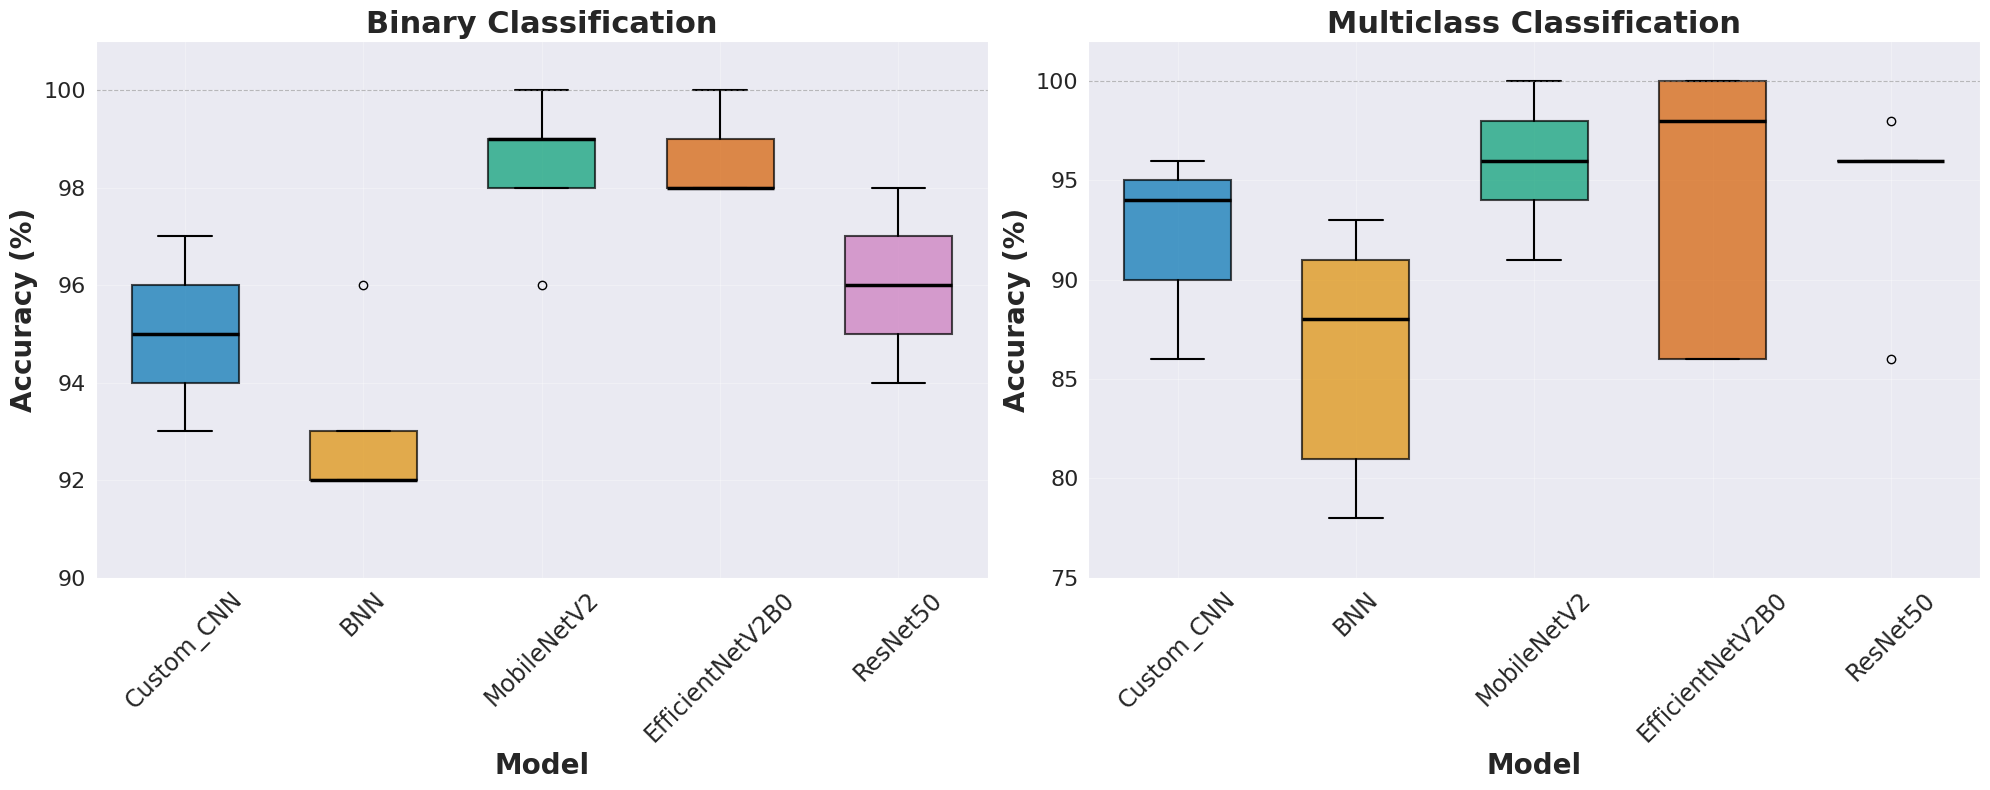

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set seaborn style
sns.set_style('darkgrid')

# Load the data
file_path = "/content/drive/My Drive/SI_1_ML_Results_Binary_Multiclass.xlsx"

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
# Filter only cross-validation folds (exclude independent test set)
df_binary_cv = df_binary[df_binary['Model'].str.contains(r'_f\d', regex=True)].copy()

# Convert accuracy to percentage
df_binary_cv['Accuracy_Percent'] = df_binary_cv['Accuracy'] * 100

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
# Filter only cross-validation folds (exclude independent test set)
df_multi_cv = df_multi[df_multi['Model'].str.contains(r'_f\d', regex=True)].copy()

# Convert accuracy to percentage
df_multi_cv['Accuracy_Percent'] = df_multi_cv['Accuracy'] * 100

# ==========================================
# DEFINE COLOR PALETTE
# ==========================================
colorblind_palette = sns.color_palette('colorblind', n_colors=5)

# ==========================================
# CREATE FIGURE WITH TWO SUBPLOTS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ==========================================
# BOXPLOT FOR BINARY CLASSIFICATION
# ==========================================
ax1 = axes[0]

# Get unique models in order
models_binary = df_binary_cv['Base_Model'].unique()

# Create boxplot
bp1 = ax1.boxplot([df_binary_cv[df_binary_cv['Base_Model'] == model]['Accuracy_Percent'].values
                    for model in models_binary],
                   tick_labels=models_binary,
                   patch_artist=True,
                   widths=0.6,
                   showmeans=False,
                   showfliers=True)

# Color the boxes
for patch, color in zip(bp1['boxes'], colorblind_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style whiskers, caps, medians
for whisker in bp1['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in bp1['caps']:
    cap.set(color='black', linewidth=1.5)
for median in bp1['medians']:
    median.set(color='black', linewidth=2.5)

ax1.set_xlabel('Model', fontsize=20, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=20, fontweight='bold')
ax1.set_title('Binary Classification', fontsize=22, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=17)
ax1.tick_params(axis='y', labelsize=16)
ax1.set_ylim(90, 101)
ax1.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.grid(True, alpha=0.3)

# ==========================================
# BOXPLOT FOR MULTICLASS CLASSIFICATION
# ==========================================
ax2 = axes[1]

# Get unique models in order
models_multi = df_multi_cv['Base_Model'].unique()

# Create boxplot
bp2 = ax2.boxplot([df_multi_cv[df_multi_cv['Base_Model'] == model]['Accuracy_Percent'].values
                   for model in models_multi],
                   tick_labels=models_multi,
                   patch_artist=True,
                   widths=0.6,
                   showmeans=False,
                   showfliers=True)

# Color the boxes
for patch, color in zip(bp2['boxes'], colorblind_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style whiskers, caps, medians
for whisker in bp2['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in bp2['caps']:
    cap.set(color='black', linewidth=1.5)
for median in bp2['medians']:
    median.set(color='black', linewidth=2.5)

ax2.set_xlabel('Model', fontsize=20, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=20, fontweight='bold')
ax2.set_title('Multiclass Classification', fontsize=22, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=17)
ax2.tick_params(axis='y', labelsize=16)
ax2.set_ylim(75, 102)
ax2.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
output_path = '/content/drive/My Drive/accuracy_boxplots_binary_multiclass.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()